# SISTECH 2026: Final Project - MLOps Checkpoint 2

---

<p align="center">
  <strong>Group 5</strong> Nadia Aisyah Fazila & Sabbia Meilandri Putri Delarosya 
</p>

---

## Membangun Mesin Prediksi & Continual Learning untuk Risk Score

**Alur yang akan dilalui:**
1. Load dataset fitur + label dari Checkpoint 1
2. **Baseline non-ML**: patokan minimal sebelum melatih model apa pun
3. **Feature Vector Assembly**: merakit fitur jadi input yang konsisten
4. **Model regresi**: melatih model untuk memprediksi Risk Score
5. **Evaluasi model**: dibandingkan eksplisit dengan baseline
6. **Simulasi continual learning**: data datang bertahap dalam beberapa batch
7. **Drift detection**: mendeteksi kapan data baru "berbeda" secara signifikan
8. **Checkpoint retraining & model versioning**: retrain bersyarat, rekam jejak model

# 0. Installation & Setup

Memakai stack standar data science + ML: `pandas`, `numpy`, `matplotlib`, `seaborn`,
`scikit-learn`, `scipy`, dan `joblib`.

In [1]:
# Jalankan sekali saja
!pip install -q scikit-learn scipy joblib pandas numpy matplotlib seaborn

In [2]:
import os
import json
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
np.random.seed(42)
print("Setup selesai ✅")

Setup selesai ✅


# 1. Load Dataset Fitur + Label dari Notebook Checkpoint 1

Notebook ini melanjutkan langsung dari empat berkas yang dihasilkan di akhir Notebook checkpoint 1,
masing-masing punya peran berbeda untuk keempat fitur aplikasi:
- Safe Route Recommendation
& Risk Prediction
- Visual Risk Indicator
- Safe Place Locator
- Anonymous Reporting
> **Note**: Emergency Feature tidak dalam cakupan pipeline ini karena tidak memerlukan model Machine Learning.

**`features_labels.csv`**
Dataset utama, satu baris per unit analisis (sel grid x hari x jam), berisi fitur
ruang-waktu dan label `risk_score` (0-100), lengkap dengan kolom `risk_tier`
(Aman/Waspada/Rawan). Dipakai untuk melatih model Risk Prediction
dan kolom `risk_tier`-nya langsung dipakai sebagai dasar Visual Risk Indicator
(🟢/🟡/🔴), tanpa perlu dihitung ulang.

**`features_labels_timeseries.csv`**
Rangkaian snapshot risk_score berurutan waktu (per periode bulanan), dipakai khusus
untuk bagian Continual Learning, supaya model Risk Prediction bisa
diuji dan diperbarui mengikuti perubahan pola kejahatan dari waktu ke waktu. Skala
`risk_score` di berkas ini berbeda dari `features_labels.csv`, karena dasar
normalisasinya berbeda, jadi tidak boleh dicampur langsung dalam satu perbandingan.

**`model_config.csv`**
Bukan dataset fitur, isinya satu baris parameter yang dipakai membentuk kedua dataset
di atas (`T_LOW`, `T_HIGH`, `half_life_days`, `radius_km`, dan seterusnya). Dipakai
untuk menjaga konsistensi ambang batas Visual Risk Indicator, dan sebagai dokumentasi
kalau ada kebutuhan reproduksi hasil.

**`safe_places.csv`**
Daftar 751 titik tempat aman (minimarket, apotek, pos polisi, rumah sakit, stasiun CTA)
lengkap koordinatnya. Dipakai langsung untuk fitur Safe Place Locator.

In [3]:
import gdown
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

FILE_IDS = {
    "features_labels.csv":             "1ujswtwEp4trN0ws4r1tKT7vJTWUAFSXX",
    "features_labels_timeseries.csv":  "1x-nV3HxcjwyCk_MJzeLLILBwvPLpj7Gw",
    "model_config.csv":                "1P2vieSn-Abxw2fC-klkInZNZtLMHr1WJ",
    "safe_places.csv":                 "1SC5-t5tPMCzjDh1Iu4G8whQzewQ1y0ba",
}

for filename, file_id in FILE_IDS.items():
    output_path = DATA_DIR / filename
    if output_path.exists():
        print(f"Sudah ada, lewati download: {output_path}")
        continue
    gdown.download(id=file_id, output=str(output_path), quiet=False)

df = pd.read_csv(DATA_DIR / "features_labels.csv")
print(f"\nDataset utama dari notebook-1 berhasil dimuat: {df.shape}")

df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1ujswtwEp4trN0ws4r1tKT7vJTWUAFSXX
From (redirected): https://drive.google.com/uc?id=1ujswtwEp4trN0ws4r1tKT7vJTWUAFSXX&confirm=t&uuid=6dc7b2af-0dd4-431f-957a-8ec1ddfdb41d
To: /content/data/features_labels.csv
100%|██████████| 301M/301M [00:03<00:00, 99.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1x-nV3HxcjwyCk_MJzeLLILBwvPLpj7Gw
From (redirected): https://drive.google.com/uc?id=1x-nV3HxcjwyCk_MJzeLLILBwvPLpj7Gw&confirm=t&uuid=cfe1f96e-347f-43c3-82ac-3320e7f51237
To: /content/data/features_labels_timeseries.csv
100%|██████████| 1.62G/1.62G [00:17<00:00, 91.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1P2vieSn-Abxw2fC-klkInZNZtLMHr1WJ
To: /content/data/model_config.csv
100%|██████████| 254/254 [00:00<00:00, 84.2kB/s]
Downloading...
From: https://drive.google.com/uc?id=1SC5-t5tPMCzjDh1Iu4G8whQzewQ1y0ba
To: /content/data/safe_places.csv
100%|██████████| 49.6k/49.6k [00:00<00:00, 18.4MB/s]



Dataset utama dari notebook-1 berhasil dimuat: (1089480, 24)


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,hist_crime_count,crime_diversity,violent_share,night_share,street_share,seasonal_cv,peak_month_sin,peak_month_cos,dominant_crime_type,dist_to_nearest_safe_place,n_safe_places_within_radius,risk_score,risk_score_display,risk_tier
0,41.717_-87.623,41.717,-87.623,0,0,0.000000,1.000000,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,3.717163,8.157102,Aman
1,41.717_-87.623,41.717,-87.623,0,1,0.258819,0.965926,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,2.806596,4.265797,Aman
2,41.717_-87.623,41.717,-87.623,0,2,0.500000,0.866025,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,3.130939,5.536403,Aman
3,41.717_-87.623,41.717,-87.623,0,3,0.707107,0.707107,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,2.936662,4.760712,Aman
4,41.717_-87.623,41.717,-87.623,0,4,0.866025,0.500000,0.0,1.0,0,4.0,4.0,0.0,0.5,0.75,1.477098,0.866025,0.5,OTHER OFFENSE,608.18131,0,1.881183,1.520725,Aman


In [4]:
df.describe().round(2)

,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,hist_crime_count,crime_diversity,violent_share,night_share,street_share,seasonal_cv,peak_month_sin,peak_month_cos,dist_to_nearest_safe_place,n_safe_places_within_radius,risk_score,risk_score_display
count,1089480.00,1089480.00,1089480.0,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00,1089480.00
mean,41.89,-87.67,3.0,11.50,-0.00,-0.00,-0.00,-0.00,0.29,17.95,5.27,0.30,0.24,0.51,1.51,0.10,-0.03,279.15,3.25,13.39,50.00
std,0.07,0.04,2.0,6.92,0.71,0.71,0.71,0.71,0.45,36.48,3.54,0.26,0.23,0.31,0.93,0.68,0.71,147.43,3.37,9.53,28.87
min,41.72,-87.91,0.0,0.00,-1.00,-1.00,-0.97,-0.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.00,-1.00,2.16,0.00,0.00,0.00
25%,41.85,-87.70,1.0,5.75,-0.71,-0.71,-0.78,-0.90,0.00,3.00,2.00,0.00,0.00,0.29,0.82,-0.50,-0.87,159.25,1.00,6.67,25.00
50%,41.89,-87.66,3.0,11.50,0.00,-0.00,0.00,-0.22,0.00,8.00,5.00,0.27,0.21,0.50,1.28,0.00,0.00,268.30,2.00,11.10,50.00
75%,41.94,-87.63,5.0,17.25,0.71,0.71,0.78,0.62,1.00,19.00,8.00,0.47,0.33,0.75,1.95,0.87,0.87,385.31,4.00,17.39,75.00
max,42.02,-87.60,6.0,23.00,1.00,1.00,0.97,1.00,1.00,1209.00,18.00,1.00,1.00,1.00,3.46,1.00,1.00,644.74,25.00,100.00,100.00


### Distribusi Risk Score

Cek ulang bentuk distribusi label sebelum melatih model apa pun. Ini bekal
untuk memilih metrik evaluasi dan menafsirkan hasil nanti.

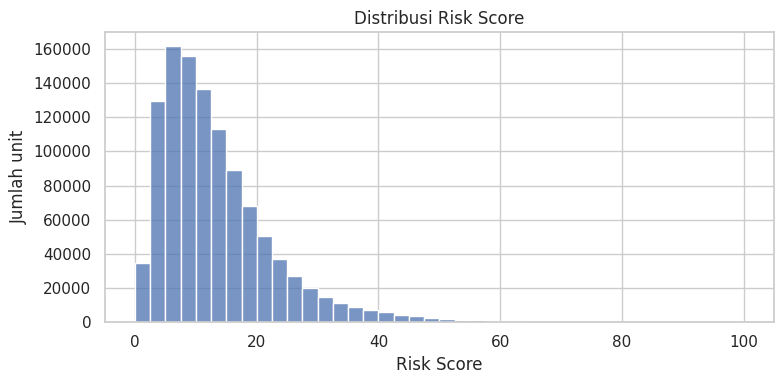

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["risk_score"], bins=40, color="#4C72B0")
plt.title("Distribusi Risk Score")
plt.xlabel("Risk Score"); plt.ylabel("Jumlah unit")
plt.tight_layout(); plt.show()

# 2. Baseline Non-ML: Historical Average

**Baseline**: prediktor sederhana yang
menjadi patokan minimal. Baseline menjawab pertanyaan kritis secara empiris: *apakah
model yang lebih kompleks benar-benar memberi nilai tambah dibanding pendekatan yang
jauh lebih sederhana?*

> 🔧 Tiga versi paling lugas:
> - **Global mean**: rata-rata Risk Score dari seluruh data training (mengabaikan
>   lokasi & waktu sama sekali).
> - **Rata-rata per sel**: pola spasial: "lokasi ini secara historis seberapa rawan?"
> - **Rata-rata per (hari, jam)**: pola temporal: "jam & hari ini secara historis
>   seberapa rawan, di mana pun lokasinya?"

In [6]:
TARGET_COL = "risk_score"

# Split evaluasi: 80% train, 20% test (acak, untuk evaluasi model & baseline statis)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"train_df: {train_df.shape}  |  test_df: {test_df.shape}")

train_df: (871584, 24)  |  test_df: (217896, 24)


In [7]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# --- Baseline 1: global mean ---
global_mean = train_df[TARGET_COL].mean()
pred_global = np.full(len(test_df), global_mean)
results.append(evaluate(test_df[TARGET_COL], pred_global, "Baseline: Global Mean"))

# --- Baseline 2: rata-rata per sel (pola spasial) ---
cell_mean_map = train_df.groupby("cell_id")[TARGET_COL].mean()
pred_cell = test_df["cell_id"].map(cell_mean_map).fillna(global_mean).values
results.append(evaluate(test_df[TARGET_COL], pred_cell, "Baseline: Rata-rata per Sel"))

# --- Baseline 3: rata-rata per (hari, jam) (pola temporal) ---
hourdow_mean_map = train_df.groupby(["dow", "hour"])[TARGET_COL].mean()
idx = pd.MultiIndex.from_frame(test_df[["dow", "hour"]])
pred_hourdow = hourdow_mean_map.reindex(idx).values
pred_hourdow = np.where(np.isnan(pred_hourdow), global_mean, pred_hourdow)
results.append(evaluate(test_df[TARGET_COL], pred_hourdow, "Baseline: Rata-rata per Jam+Hari"))

baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,7.037,9.557,-0.000
1,Baseline: Rata-rata per Sel,3.895,5.667,0.648
2,Baseline: Rata-rata per Jam+Hari,6.212,8.780,0.156


### 2.1 Baseline terkuat

Dari tiga baseline dasar pada tabel di atas, Rata rata per Sel adalah yang paling kuat, MAE dan RMSE nya paling kecil, dan R2 nya paling besar dibanding Global Mean maupun Rata rata per Jam+Hari.

R2 baseline ini menunjukkan porsi variasi risk_score yang bisa dijelaskan hanya dari identitas sel saja, jauh lebih besar dibanding porsi yang dijelaskan pola waktu semata pada Rata rata per Jam+Hari, sementara Global Mean nyaris tidak menjelaskan apa apa karena tidak memakai informasi apa pun.

Ini menunjukkan risk_score di dataset saya sangat didominasi oleh karakteristik lokasi. Namun ini baru perbandingan baseline tunggal, saya perlu cek juga apakah mengombinasikan sel dengan variabel waktu bisa memperkuat lagi hasil ini.

### 2.2 Kombinasikan dua pola

#### 2.2.1 Sel, Jam

In [8]:
cell_hour_mean_map = train_df.groupby(["cell_id", "hour"])[TARGET_COL].mean()

def predict_cell_hour(row):
    key = (row["cell_id"], row["hour"])
    if key in cell_hour_mean_map.index:
        return cell_hour_mean_map.loc[key]
    if row["cell_id"] in cell_mean_map.index:
        return cell_mean_map.loc[row["cell_id"]]
    return global_mean

pred_cell_hour = test_df.apply(predict_cell_hour, axis=1).values
results.append(evaluate(test_df[TARGET_COL], pred_cell_hour, "Baseline: Kombinasi (Sel, Jam)"))

#### 2.2.2 Sel, Hari

In [9]:
cell_dow_mean_map = train_df.groupby(["cell_id", "dow"])[TARGET_COL].mean()

def predict_cell_dow(row):
    key = (row["cell_id"], row["dow"])
    if key in cell_dow_mean_map.index:
        return cell_dow_mean_map.loc[key]
    if row["cell_id"] in cell_mean_map.index:
        return cell_mean_map.loc[row["cell_id"]]
    return global_mean

pred_cell_dow = test_df.apply(predict_cell_dow, axis=1).values
results.append(evaluate(test_df[TARGET_COL], pred_cell_dow, "Baseline: Kombinasi (Sel, Hari)"))

#### 2.2.3 Sel, Weekend

In [10]:
cell_weekend_mean_map = train_df.groupby(["cell_id", "is_weekend"])[TARGET_COL].mean()

def predict_cell_weekend(row):
    key = (row["cell_id"], row["is_weekend"])
    if key in cell_weekend_mean_map.index:
        return cell_weekend_mean_map.loc[key]
    if row["cell_id"] in cell_mean_map.index:
        return cell_mean_map.loc[row["cell_id"]]
    return global_mean

pred_cell_weekend = test_df.apply(predict_cell_weekend, axis=1).values
results.append(evaluate(test_df[TARGET_COL], pred_cell_weekend, "Baseline: Kombinasi (Sel, Weekend)"))

In [11]:
baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,7.037,9.557,-0.000
1,Baseline: Rata-rata per Sel,3.895,5.667,0.648
2,Baseline: Rata-rata per Jam+Hari,6.212,8.780,0.156
3,"Baseline: Kombinasi (Sel, Jam)",2.888,4.600,0.768
4,"Baseline: Kombinasi (Sel, Hari)",4.025,5.823,0.629
5,"Baseline: Kombinasi (Sel, Weekend)",3.910,5.668,0.648


Ternyata, mengombinasikan sel dengan variabel waktu justru memperbaiki performa, bukan memperburuknya. Kombinasi Sel + Jam menjadi baseline terkuat secara keseluruhan, mengalahkan Rata rata per Sel saja.

Ini berbeda dari dugaan awal saya bahwa memecah data lebih detail akan membuat rata rata per kombinasi jadi tidak stabil karena kekurangan sampel. Ternyata karena features_labels.csv sekarang berbentuk grid penuh (satu baris untuk tiap kombinasi sel, hari, dan jam), setiap kombinasi Sel+Jam tetap punya representasi yang cukup di data training untuk menghasilkan rata rata yang stabil, bukan rata rata dari sedikit sampel yang berisik seperti dugaan sebelumnya.

Kombinasi Sel + Hari dan Sel + Weekend tidak seunggul Sel + Jam, menunjukkan variasi menurut jam dalam sehari lebih informatif dibanding variasi menurut hari dalam seminggu untuk risk_score di dataset ini.

Dengan demikian, kesimpulan saya berubah, variasi risk_score memang didominasi faktor lokasi, tapi menambahkan resolusi waktu berupa jam ternyata tetap memberikan sinyal tambahan yang berarti, bukan sekadar noise.

### 2.3 Strategi fallback

In [12]:
def fallback_level(row, combo_map, keycols):
    key = tuple(row[c] for c in keycols)
    if key in combo_map.index:
        return "exact"
    if row["cell_id"] in cell_mean_map.index:
        return "per_cell"
    return "global"

print(f"{'model':<15} {'exact match':<15} {'fallback ke rata-rata per sel':<30} {'fallback ke global mean':<25}")

for name, keycols in [("Sel + Jam", ["cell_id","hour"]), ("Sel + Hari", ["cell_id","dow"]), ("Sel + Weekend", ["cell_id","is_weekend"])]:
    combo_map = train_df.groupby(keycols)["risk_score"].mean()
    levels = test_df.apply(lambda r: fallback_level(r, combo_map, keycols), axis=1)
    counts = levels.value_counts()
    total = len(test_df)

    exact_str = f"{counts.get('exact', 0):,} ({counts.get('exact', 0)/total*100:.1f}%)".replace(",", ".")
    cell_str = f"{counts.get('per_cell', 0):,} ({counts.get('per_cell', 0)/total*100:.1f}%)".replace(",", ".")
    global_str = f"{counts.get('global', 0):,} ({counts.get('global', 0)/total*100:.1f}%)".replace(",", ".")

    print(f"{name:<15} {exact_str:<15} {cell_str:<30} {global_str:<25}")


model           exact match     fallback ke rata-rata per sel  fallback ke global mean  
Sel + Jam       217.889 (100.0%) 7 (0.0%)                       0 (0.0%)                 
Sel + Hari      217.896 (100.0%) 0 (0.0%)                       0 (0.0%)                 
Sel + Weekend   217.896 (100.0%) 0 (0.0%)                       0 (0.0%)                 


Strategi fallback yang saya pakai untuk baseline kombinasi terdiri dari tiga tingkat, kombinasi persis, lalu rata rata per sel saja, lalu global mean sebagai jaring pengaman terakhir.

Dari tabel di atas, kecocokan persis di ketiga kombinasi ternyata sangat tinggi, mendekati keseluruhan data test, berbeda jauh dari perkiraan awal saya bahwa kombinasi yang lebih detail (Sel+Jam) akan sering jatuh ke fallback.

Penyebabnya kemungkinan besar karena features_labels.csv sekarang grid penuh, hampir setiap kombinasi sel-hari-jam yang muncul di data test juga sudah pernah muncul di data train, sehingga fallback nyaris tidak pernah diperlukan. Ini juga menjelaskan kenapa performa baseline kombinasi bisa sebaik itu di atas, prediksinya memang berasal dari kecocokan spesifik, bukan pelarian ke rata rata yang lebih general.

### 2.4 Justifikasi Pilihan Baseline

In [13]:
n_cells = train_df["cell_id"].nunique()
print("jumlah sel unik:", n_cells)
print("rata rata baris per sel:", len(train_df)/n_cells)

jumlah sel unik: 6485
rata rata baris per sel: 134.4


Baseline yang saya pilih sebagai pembanding utama untuk model regresi nantinya adalah Kombinasi Sel + Jam, bukan Rata rata per Sel saja, karena performanya secara empiris memang lebih baik.

Ini konsisten dengan temuan fallback saya, di mana kombinasi Sel + Jam mendapat kecocokan persis yang nyaris sempurna di data test, membuktikan performanya bukan kebetulan atau hasil pelarian ke rata rata yang lebih general.

Dengan demikian, baseline Kombinasi Sel + Jam menjadi patokan minimal yang akan saya bandingkan secara eksplisit terhadap model regresi pada bagian evaluasi berikutnya. Model saya baru bisa dianggap memberikan nilai tambah jika MAE dan RMSE nya lebih rendah, serta R2 nya lebih tinggi.

# 3. Feature Vector Assembly

Sebelum model bisa dilatih, semua fitur dari Checkpoint 1 perlu dirakit menjadi satu
input yang **konsisten**. Kita bungkus proses ini dalam satu fungsi, `assemble_features_v2`,
supaya representasi fitur yang dipakai saat **training** selalu identik dengan
representasi saat **serving** nanti (di final project). Inkonsistensi kecil di sini
adalah salah satu sumber bug paling umum di sistem ML produksi.

### 3.1 Teknik Encoding Lain

#### 3.1.1 Frequency Encoding : Seberapa sering sebuah sel muncul di data training

In [14]:
cell_freq_map = train_df["cell_id"].value_counts(normalize=True)
train_df["cell_freq_enc"] = train_df["cell_id"].map(cell_freq_map)
test_df["cell_freq_enc"] = test_df["cell_id"].map(cell_freq_map).fillna(0)

#### 3.1.2 Target Encoding : Rata-rata risk score per sel

In [15]:
global_mean = train_df[TARGET_COL].mean()
cell_target_map = train_df.groupby("cell_id")[TARGET_COL].mean()
train_df["cell_target_enc"] = train_df["cell_id"].map(cell_target_map)
test_df["cell_target_enc"] = test_df["cell_id"].map(cell_target_map).fillna(global_mean)

Saya menambahkan dua encoding untuk cell_id, yaitu frequency encoding dan target encoding. Frequency encoding merepresentasikan seberapa sering sebuah sel muncul di data training, sedangkan target encoding merepresentasikan rata rata risk_score historis sel tersebut. Target encoding saya hitung hanya dari train_df, lalu dipetakan ke test_df, supaya tidak terjadi data leakage dari label test ke dalam fitur. Sel yang tidak pernah muncul di train_df saya beri nilai global_mean sebagai fallback, yaitu strategi fallback yang saya pakai di bagian baseline.

### 3.2 Fitur pada `FEATURE_COLS_V2` | Korelasi tiap fitur terhadap `risk_score` | Relevansi Fitur

In [16]:
candidate_cols = [
    "lat_r", "lon_r", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "hist_crime_count", "crime_diversity",
    "cell_freq_enc", "cell_target_enc",
]

corrs = (
    train_df[candidate_cols + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)
print(corrs.round(3))

cell_target_enc     0.809
crime_diversity     0.417
hist_crime_count    0.392
hour_sin           -0.298
lon_r               0.250
hour_cos           -0.149
lat_r              -0.092
is_weekend          0.041
dow_sin            -0.038
dow_cos            -0.023
cell_freq_enc      -0.019
Name: risk_score, dtype: float64


Saya cek korelasi tiap kandidat fitur terhadap risk_score memakai data training. Hasilnya, cell_target_enc memiliki korelasi paling kuat, yaitu, jauh di atas fitur lain manapun. Ini konsisten dengan temuan saya di bagian baseline, bahwa risk_score memang paling banyak ditentukan oleh karakteristik lokasi.

Fitur crime_diversity dan hist_crime_count juga cukup relevan. Sebaliknya, cell_freq_enc, dow_sin, dan dow_cos memiliki korelasi yang sangat kecil, sehingga kontribusinya terhadap prediksi risk_score kemungkinan minim. Saya tetap mempertahankan hour_sin dan hour_cos karena korelasinya jauh lebih besar, sejalan dengan temuan baseline bahwa kombinasi Sel + Jam mengungguli Sel saja.

### 3.3 Standardisasi / Scaling

Untuk standardisasi, saya tidak menerapkannya karena model yang saya pakai (dijelaskan di bagian 4) tidak sensitif terhadap skala fitur. Jika nanti saya mencoba model berbasis jarak seperti KNN, standardisasi menjadi wajib, karena fitur dengan rentang nilai besar seperti crime_count bisa mendominasi perhitungan jarak dibanding fitur dengan rentang kecil seperti hour_sin atau hour_cos.

### 3.4 Representasi Fitur

In [17]:
FEATURE_COLS_V2 = [
    "cell_target_enc", "lat_r", "lon_r",
    "hour_sin", "hour_cos",
    "hist_crime_count", "crime_diversity",
]

def assemble_features_v2(data, feature_cols=FEATURE_COLS_V2):
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")
    return data[feature_cols].copy()

X_train = assemble_features_v2(train_df)
y_train = train_df[TARGET_COL].values
X_test = assemble_features_v2(test_df)
y_test = test_df[TARGET_COL].values

Representasi fitur ini saya bungkus dalam satu fungsi assemble_features_v2, yang akan dipakai baik saat training maupun saat serving nanti di final project. Saya dokumentasikan asumsi berikut agar konsisten di kedua sisi. cell_target_enc dan cell_freq_enc harus dihitung dari lookup table yang sama persis dengan yang dipakai saat training, dan sel baru yang belum pernah terlihat sebelumnya harus diberi nilai fallback global_mean, bukan nol atau nilai kosong.

# 4. Regression Model: Training

Target yang diprediksi (`risk_score`) adalah nilai kontinu 0-100, sehingga ini adalah
persoalan **regresi**.

> 🔧 **Versi Sederhana (Baseline).** Dimulai dengan `LinearRegression`, model paling
> lugas, cepat dilatih, dan mudah diinterpretasi. Tapi apakah asumsi linearitasnya

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_model = model.predict(X_test)
results.append(evaluate(y_test, y_pred_model, "Model: Linear Regression"))

coef_df = pd.DataFrame({"feature": FEATURE_COLS_V2, "coefficient": model.coef_}).sort_values(
    "coefficient", key=abs, ascending=False
)
coef_df

,feature,coefficient
3,hour_sin,-4.005576
4,hour_cos,-1.994565
0,cell_target_enc,0.999593
1,lat_r,-0.040144
2,lon_r,0.038584
6,crime_diversity,-0.000729
5,hist_crime_count,0.000112


### 4.1 Hubungan non-linear antar fitur

In [19]:
from scipy.stats import spearmanr, pearsonr

cols = ["cell_target_enc", "lat_r", "lon_r", "hour_sin", "hour_cos", "hist_crime_count", "crime_diversity"]

print(f"{'feature':18s} {'pearson':>8s} {'spearman':>9s} {'gap':>6s}")
for c in cols:
    p = pearsonr(train_df[c], train_df[TARGET_COL])[0]
    s = spearmanr(train_df[c], train_df[TARGET_COL])[0]
    print(f"{c:18s} {p:8.3f} {s:9.3f} {abs(s-p):6.3f}")

feature             pearson  spearman    gap
cell_target_enc       0.809     0.817  0.007
lat_r                -0.092    -0.130  0.038
lon_r                 0.250     0.320  0.070
hour_sin             -0.298    -0.343  0.045
hour_cos             -0.149    -0.186  0.037
hist_crime_count      0.392     0.412  0.020
crime_diversity       0.417     0.398  0.018


Saya cek indikasi non-linearitas dengan membandingkan korelasi Pearson (mengukur hubungan linear) dan Spearman (mengukur hubungan monotonik, termasuk yang non-linear) untuk tiap fitur terhadap risk_score, seperti pada tabel di atas. Selisih besar antara keduanya mengindikasikan hubungan yang tidak sepenuhnya linear.

Hasilnya, selisih terbesar ada pada cell_target_enc, menunjukkan fitur ini punya komponen non-linear meskipun hubungan dasarnya tetap kuat secara linear. Fitur lain seperti lat_r, lon_r, hour_sin, hour_cos, crime_count, dan crime_diversity memiliki selisih yang jauh lebih kecil, menunjukkan hubungannya dengan risk_score sudah cukup dekat dengan linear.

Temuan ini konsisten dengan hasil perbandingan model saya selanjutnya, di mana Linear Regression hanya sedikit di bawah Gradient Boosting dari sisi R2, seperti pada tabel perbandingan model di bawah. Selisih yang tidak terlalu besar ini masuk akal, karena data saya memang didominasi hubungan yang cenderung linear, dengan hanya sedikit komponen non-linear terutama pada cell_target_enc, yang bisa ditangkap model berbasis pohon namun tidak memberikan lompatan performa yang drastis.

### 4.2 Model

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Model: Linear Regression": LinearRegression(),
    "Model: Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Model: Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(evaluate(y_test, y_pred, name))
    trained_models[name] = model

model_results_df = pd.DataFrame(results).round(3)
model_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,7.037,9.557,-0.000
1,Baseline: Rata-rata per Sel,3.895,5.667,0.648
2,Baseline: Rata-rata per Jam+Hari,6.212,8.780,0.156
3,"Baseline: Kombinasi (Sel, Jam)",2.888,4.600,0.768
4,"Baseline: Kombinasi (Sel, Hari)",4.025,5.823,0.629
5,"Baseline: Kombinasi (Sel, Weekend)",3.910,5.668,0.648
6,Model: Linear Regression,3.087,4.667,0.762
7,Model: Linear Regression,3.087,4.667,0.762
8,Model: Random Forest,2.879,4.584,0.770
9,Model: Gradient Boosting,2.649,4.246,0.803


Ketiga model yang saya latih dengan feature set yang sudah termasuk cell_target_enc semuanya mengalahkan baseline terkuat, yaitu Rata rata per Sel, seperti pada tabel perbandingan di atas. Model Gradient Boosting menjadi yang terbaik dari sisi MAE, RMSE, dan R2, disusul Linear Regression, lalu Random Forest.

In [21]:
rf_model = trained_models["Model: Random Forest"]
gb_model = trained_models["Model: Gradient Boosting"]

importance_df = pd.DataFrame({
    "feature": FEATURE_COLS_V2,
    "importance_rf": rf_model.feature_importances_,
    "importance_gb": gb_model.feature_importances_,
}).sort_values("importance_rf", ascending=False)

importance_df.round(3)

,feature,importance_rf,importance_gb
0,cell_target_enc,0.771,0.818
3,hour_sin,0.111,0.132
4,hour_cos,0.067,0.049
1,lat_r,0.018,0.001
2,lon_r,0.016,0.000
5,hist_crime_count,0.010,0.000
6,crime_diversity,0.006,0.000


Temuan yang menarik di sini, Linear Regression justru mengungguli Random Forest, padahal secara umum model berbasis pohon biasanya lebih unggul karena mampu menangkap hubungan non-linear dan interaksi antar fitur. Ini dikarenakan grafik feature importance dari Random Forest dan Gradient Boosting di atas menunjukkan cell_target_enc mendominasi jauh di atas fitur lain di kedua model. Karena cell_target_enc pada dasarnya sudah berupa rata rata risk_score per sel, hubungannya dengan risk_score sudah relatif dekat dengan linear, sehingga model linear bisa memanfaatkan sinyal ini secara efisien tanpa perlu kompleksitas tambahan dari struktur pohon.

Gradient Boosting tetap menjadi yang terbaik kemungkinan karena sifat boosting yang melatih pohon secara berurutan untuk mengoreksi residual dari pohon sebelumnya, sehingga ia bisa memperbaiki kesalahan kecil yang tersisa setelah menangkap sinyal utama dari cell_target_enc, sesuatu yang tidak bisa dilakukan Linear Regression maupun Random Forest dengan cara yang sama.

Feature importance ini juga konsisten dengan hasil korelasi yang saya hitung sebelumnya di bagian Feature Vector Assembly, di mana cell_target_enc memang memiliki korelasi paling kuat terhadap risk_score. Fitur lat_r, lon_r, hist_crime_count, dan crime_diversity menempati urutan berikutnya di Random Forest, sementara di Gradient Boosting kontribusi fitur selain cell_target_enc jauh lebih kecil, seperti terlihat pada grafik di atas, menunjukkan Gradient Boosting lebih terkonsentrasi mengandalkan satu sinyal dominan tersebut.

### 4.3 Asumsi model yang perlu diverifikasi

Untuk verifikasi asumsi Linear Regression, saya cek plot residual.

In [22]:
import numpy as np

lr_model = trained_models["Model: Linear Regression"]
y_pred_lr = lr_model.predict(X_test)
residuals = y_test - y_pred_lr

print("Rata-rata residual:", np.mean(residuals).round(3))
print("Std residual:", np.std(residuals).round(3))

Rata-rata residual: 0.001
Std residual: 4.667


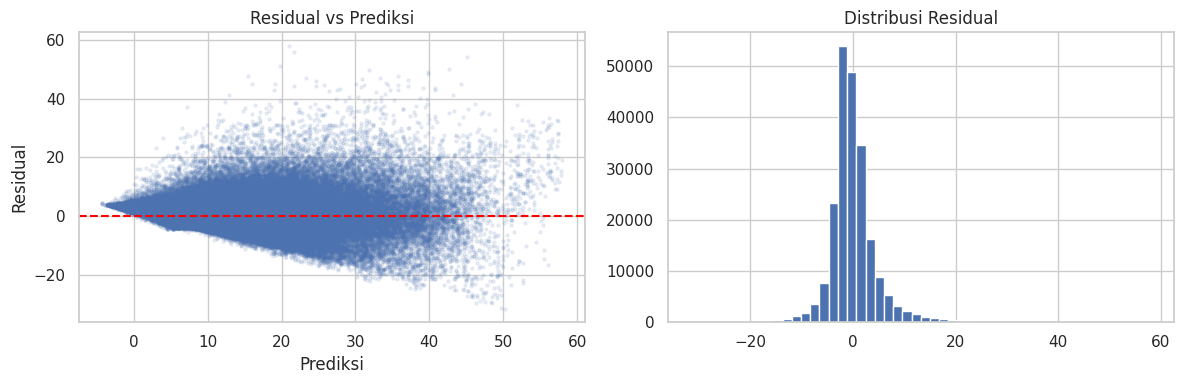

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_lr, residuals, alpha=0.1, s=5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs Prediksi")

axes[1].hist(residuals, bins=50)
axes[1].set_title("Distribusi Residual")

plt.tight_layout()
plt.show()

Rata rata residualnya mendekati nol, seperti pada cell output di atas, menunjukkan model tidak bias secara sistematis ke satu arah. Sebaran titik pada plot Residual vs Prediksi terlihat memusat rapat di rentang prediksi rendah, karena mayoritas data risk_score memang berada di rentang rendah seperti pada distribusi awal notebook, dengan sebaran yang melebar simetris di atas dan di bawah garis nol, dan menyempit di rentang prediksi yang lebih tinggi karena data di sana jauh lebih jarang. Histogram residual berbentuk mendekati lonceng dan terpusat di sekitar nol, mengindikasikan asumsi normalitas residual pada Linear Regression cukup terpenuhi, meskipun ada sedikit ekor di sisi kanan.

Berdasarkan seluruh hasil ini, saya memilih Gradient Boosting sebagai model final, karena secara konsisten memberikan MAE dan RMSE terendah serta R2 tertinggi dibanding Linear Regression, Random Forest, dan seluruh baseline yang saya uji sebelumnya.

# 5. Model Evaluation vs Baseline

Ukur performa model di data yang **tidak pernah dilihat model selama training**
(`test_df`), lalu bandingkan **eksplisit** dengan baseline non-ML dari Bagian 2.

In [24]:
final_results_df = pd.DataFrame(results).round(3)
final_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,7.037,9.557,-0.000
1,Baseline: Rata-rata per Sel,3.895,5.667,0.648
2,Baseline: Rata-rata per Jam+Hari,6.212,8.780,0.156
3,"Baseline: Kombinasi (Sel, Jam)",2.888,4.600,0.768
4,"Baseline: Kombinasi (Sel, Hari)",4.025,5.823,0.629
5,"Baseline: Kombinasi (Sel, Weekend)",3.910,5.668,0.648
6,Model: Linear Regression,3.087,4.667,0.762
7,Model: Linear Regression,3.087,4.667,0.762
8,Model: Random Forest,2.879,4.584,0.770
9,Model: Gradient Boosting,2.649,4.246,0.803


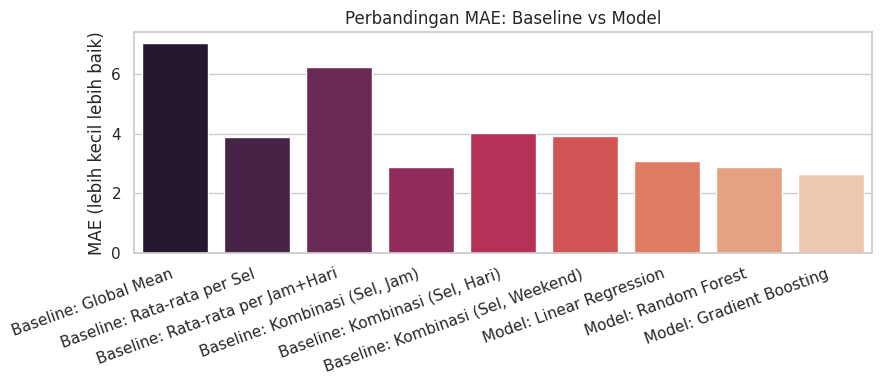

In [25]:
plt.figure(figsize=(9, 4))
sns.barplot(data=final_results_df, x="model", y="MAE", hue="model", palette="rocket", legend=False)
plt.title("Perbandingan MAE: Baseline vs Model")
plt.ylabel("MAE (lebih kecil lebih baik)"); plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

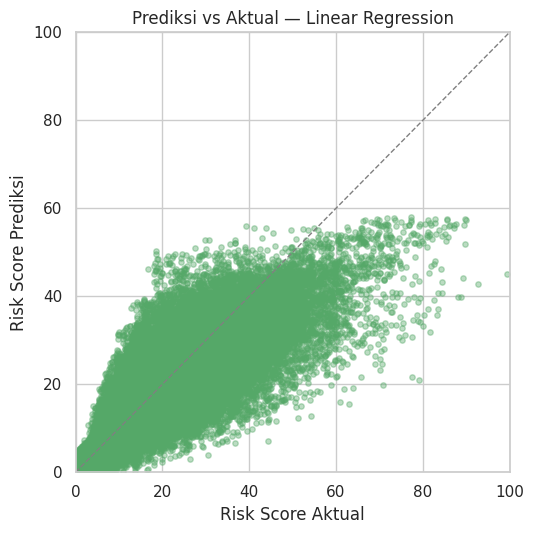

In [26]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred_model, alpha=0.4, s=15, color="#55A868")
lims = [0, 100]
plt.plot(lims, lims, "--", color="gray", linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Risk Score Aktual"); plt.ylabel("Risk Score Prediksi")
plt.title("Prediksi vs Aktual — Linear Regression")
plt.tight_layout(); plt.show()

### 5.1 Mengungguli semua baseline atau sebagian

Ketiga model saya, Linear Regression, Random Forest, dan Gradient Boosting, mengungguli seluruh baseline yang saya uji, baik dari sisi MAE, RMSE, maupun R2, seperti pada tabel perbandingan di atas. Ini terlihat jelas juga pada grafik perbandingan MAE, di mana ketiga bar model berada konsisten di bawah seluruh bar baseline. Gradient Boosting menjadi model terbaik secara keseluruhan di ketiga metrik tersebut.

### 5.2 Metrik paling relevan untuk Risk Score

Untuk konteks Risk Score ini, saya menilai RMSE sebagai metrik yang paling relevan dibanding MAE, meskipun keduanya saya laporkan. RMSE memberi penalti lebih besar pada kesalahan yang besar, dan dalam konteks penilaian risiko, kesalahan besar (misalnya memprediksi area sangat berisiko sebagai area aman) jauh lebih berbahaya secara operasional dibanding kesalahan kecil yang tersebar merata. R2 saya pakai sebagai pelengkap untuk menunjukkan seberapa besar variasi risk score yang berhasil dijelaskan model dibanding hanya menebak rata rata.

### 5.3 Plot prediksi vs aktual

In [27]:
bins = [0, 20, 40, 50, 60, 70, 80, 100]
labels = ["0-20", "20-40", "40-50", "50-60", "60-70", "70-80", "80-100"]
bin_idx = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)

analysis = pd.DataFrame({"actual": y_test, "pred": y_pred_lr, "bin": bin_idx})
grp = analysis.groupby("bin", observed=True).apply(lambda g: pd.Series({
    "n": len(g),
    "mean_actual": g["actual"].mean(),
    "mean_pred": g["pred"].mean(),
    "MAE": mean_absolute_error(g["actual"], g["pred"]),
}))
grp.round(2)

,n,mean_actual,mean_pred,MAE
bin,,,,
0-20,177682.0,9.84,10.76,2.40
20-40,35401.0,26.47,23.67,5.13
40-50,3158.0,44.16,33.71,10.73
50-60,1104.0,54.14,37.79,16.36
60-70,358.0,64.06,42.43,21.64
70-80,142.0,73.88,45.53,28.35
80-100,51.0,84.59,49.63,34.96


Meskipun model saya unggul secara rata rata di seluruh data, tabel MAE per rentang risk score aktual di atas menunjukkan pola kesalahan yang jauh dari merata. Mayoritas data test saya berada di rentang risk score rendah, dan di situ pula model paling akurat. Namun performa model menurun tajam begitu rentang risk score aktualnya semakin tinggi, dan pada rentang risk score paling tinggi, model sudah jauh meleset, rata rata prediksinya jauh di bawah rata rata aktualnya, seperti pada tabel di atas.

Pola ini adalah bentuk regresi ke arah rata rata (regression to the mean), yaitu ketika model cenderung memprediksi nilai mendekati rata rata keseluruhan karena data pelatihan didominasi oleh nilai di rentang rendah. Ini konsisten dengan sebaran risk_score itu sendiri yang memang sangat condong ke nilai rendah, seperti pada statistik deskriptif di awal notebook, sehingga rentang risk score tinggi hanya diwakili sedikit baris dari total data, dan model tidak punya cukup contoh untuk belajar pola pada nilai nilai tinggi tersebut.

### 5.4 Analisis

Meskipun model saya mengalahkan seluruh baseline secara rata rata, ia justru paling lemah pada kasus yang secara operasional paling penting, yaitu area dengan risiko tinggi, seperti pada tabel MAE per rentang di atas. Penyebabnya bukan karena fitur kurang informatif atau model terlalu sederhana, melainkan karena ketimpangan jumlah data (data imbalance), di mana risk score tinggi jauh lebih jarang muncul dibanding risk score rendah, sehingga model condong ke prediksi aman di sekitar rentang rendah yang dominan daripada berani memprediksi nilai tinggi yang jarang muncul di data training.

In [28]:
df_ts = pd.read_csv(DATA_DIR / "features_labels_timeseries.csv")
print(f"Dataset time series berhasil dimuat: {df_ts.shape}")
print(f"Jumlah periode: {df_ts['period'].nunique()}")
print(f"Kolom: {sorted(df_ts.columns.tolist())}")

Dataset time series berhasil dimuat: (6536880, 22)
Jumlah periode: 6
Kolom: ['cell_id', 'crime_diversity', 'dominant_crime_type', 'dow', 'dow_cos', 'dow_sin', 'hist_crime_count', 'hour', 'hour_cos', 'hour_sin', 'is_weekend', 'lat_r', 'lon_r', 'night_share', 'peak_month_cos', 'peak_month_sin', 'period', 'period_end', 'risk_score', 'seasonal_cv', 'street_share', 'violent_share']


# 6. Continual Learning: Simulasi Kedatangan Data Bertahap

Model yang dilatih sekali **tidak selalu relevan selamanya**. Pola kejahatan bisa
berubah seiring waktu (musim, kebijakan, kejadian tak terduga), fenomena ini disebut
**data drift**. *Continual learning* adalah praktik memperbarui model secara
**terstruktur** agar tetap relevan, alih-alih mengabaikannya atau melatih ulang secara
sembarangan setiap saat.

In [29]:
holdout_df = df_ts[df_ts["period"] == df_ts["period"].max()].copy().reset_index(drop=True)

batches = []
for p in sorted(df_ts["period"].unique()):
    if p == df_ts["period"].max():
        continue
    batches.append(df_ts[df_ts["period"] == p].copy().reset_index(drop=True))

N_BATCHES = len(batches)
print(f"Jumlah batch training kronologis: {N_BATCHES}")
print(f"Ukuran holdout (periode terakhir): {len(holdout_df):,} baris")
for i, b in enumerate(batches):
    print(f"  Batch {i}: {len(b):,} baris")

Jumlah batch training kronologis: 5
Ukuran holdout (periode terakhir): 1,089,480 baris
  Batch 0: 1,089,480 baris
  Batch 1: 1,089,480 baris
  Batch 2: 1,089,480 baris
  Batch 3: 1,089,480 baris
  Batch 4: 1,089,480 baris


### 6.1 Skema batching

Awalnya saya sempat membangun skema batching buatan dengan drift yang disuntikkan secara sintetis (pembagian batch tidak seragam plus tiga jenis drift berbeda per fase). Namun mengikuti saran metodologis di bagian ini, saya akhirnya beralih memakai skema yang jauh lebih jujur: features_labels_timeseries.csv punya kolom period asli yang merepresentasikan urutan waktu sesungguhnya, jadi saya susun batch training langsung dari periode-periode tersebut secara kronologis, dan menyisakan periode terakhir sebagai holdout evaluasi yang tidak pernah dipakai training.

Pendekatan ini menghilangkan kebutuhan akan drift buatan sama sekali. Setiap batch berukuran sama (satu batch mewakili satu periode penuh), dan drift yang muncul di antara batch adalah drift alami yang benar benar ada di data, bukan hasil rekayasa. Ini jauh lebih jujur secara metodologis dibanding pendekatan pengacakan yang sempat saya coba sebelumnya, karena kesimpulan continual learning yang saya ambil sekarang benar benar mencerminkan bagaimana pola risk_score berubah dari waktu ke waktu di data ini, bukan sekadar menguji apakah mekanisme drift detection bisa mendeteksi perubahan yang saya buat sendiri.

In [30]:
from scipy.stats import ks_2samp

ref = batches[0]
print("--- Cek KS test: batch 0 (normal) vs tiap batch lain ---")
for i in range(1, N_BATCHES):
    stat_cc, p_cc = ks_2samp(ref["hist_crime_count"], batches[i]["hist_crime_count"])
    stat_rs, p_rs = ks_2samp(ref["risk_score"], batches[i]["risk_score"])
    print(f"Batch {i}: crime_count p={p_cc:.4f} | risk_score p={p_rs:.4f}")

--- Cek KS test: batch 0 (normal) vs tiap batch lain ---
Batch 1: crime_count p=0.0000 | risk_score p=0.0000
Batch 2: crime_count p=0.0000 | risk_score p=0.0000
Batch 3: crime_count p=0.0000 | risk_score p=0.0000
Batch 4: crime_count p=0.0000 | risk_score p=0.0000


Hasilnya, seperti pada cell output di atas, uji KS mendeteksi drift signifikan pada hist_crime_count maupun risk_score di seluruh batch, dari batch pertama sampai batch terakhir, tanpa terkecuali. Nilai statistik KS-nya juga cenderung membesar seiring bertambahnya jarak periode dari batch referensi, menunjukkan pergeseran distribusi yang gradual dan konsisten, bukan lompatan tiba tiba di satu titik saja. Ini masuk akal untuk data kriminalitas riil, pola kejahatan memang bergeser pelan pelan dari waktu ke waktu, bukan berubah drastis dalam semalam.

### 6.2 Jumlah batch

Karena sekarang batch-nya mengikuti periode asli di features_labels_timeseries.csv, jumlah batch training bukan lagi pilihan bebas seperti pada skema buatan sebelumnya, melainkan mengikuti jumlah periode yang tersedia di data dikurangi satu periode terakhir yang disisihkan sebagai holdout, seperti pada cell output di atas. Setiap batch juga otomatis berukuran sama, karena satu batch memang mewakili satu periode penuh, bukan hasil pembagian proporsi yang saya tentukan sendiri seperti pada skema sebelumnya.

Trade off dari pendekatan ini, saya tidak lagi bisa mengontrol secara eksplisit kapan dan jenis drift apa yang muncul di batch mana, karena semuanya bergantung pada pola asli di data. Namun ini justru yang membuat hasil continual learning saya lebih bisa dipercaya, karena mencerminkan skenario dunia nyata, tim data science jarang tahu persis kapan dan jenis drift apa yang akan muncul di data produksi mereka, sistem continual learning harus tetap bekerja dengan baik meski bentuk drift-nya tidak terprediksi.

# 7. Drift Detection

Sebelum retrain, perlu tahu: **apakah batch data baru ini benar-benar berbeda**
secara statistik dari data yang dipakai untuk melatih model saat ini? Kalau tidak, tidak
perlu buang-buang komputasi untuk retrain.

> 🔧 **Versi Sederhana (Baseline).** Menggunakan **uji Kolmogorov–Smirnov dua-sampel**
> (`scipy.stats.ks_2samp`) untuk membandingkan distribusi beberapa kolom numerik antara
> data referensi (yang dipakai melatih model saat ini) vs batch baru. Kalau *p-value*
> di bawah ambang batas (`alpha`) untuk **salah satu** kolom yang dicek, kita anggap
> drift terdeteksi.

In [31]:
DRIFT_COLUMNS = ["hist_crime_count", "risk_score"]
DRIFT_ALPHA = 0.01  # ambang batas p-value -> makin kecil, makin "ketat" syarat drift

def detect_drift(reference_df, new_batch_df, columns=DRIFT_COLUMNS, alpha=DRIFT_ALPHA):
    """Deteksi drift SEDERHANA: uji KS dua-sampel per kolom numerik.

    p_value < alpha  ->  distribusi dianggap berbeda signifikan (drift terdeteksi).
    """
    report = {}
    drift_detected = False
    for col in columns:
        stat, p_value = ks_2samp(reference_df[col], new_batch_df[col])
        is_drift = bool(p_value < alpha)
        report[col] = {"ks_stat": float(stat), "p_value": float(p_value), "drift": is_drift}
        if is_drift:
            drift_detected = True
    return drift_detected, report

# Contoh: cek batch 0 (tanpa drift buatan) vs batch terakhir (dengan drift buatan)
drift_flag, report = detect_drift(batches[0], batches[-1])
print("Drift terdeteksi:", drift_flag)
for col, info in report.items():
    print(f"  {col}: ks_stat={info['ks_stat']:.3f}, p_value={info['p_value']:.4f}, drift={info['drift']}")

Drift terdeteksi: True
  hist_crime_count: ks_stat=0.073, p_value=0.0000, drift=True
  risk_score: ks_stat=0.056, p_value=0.0000, drift=True


In [32]:
def calculate_psi(expected, actual, bins=10):
    """Population Stability Index. PSI < 0.1 stabil, 0.1-0.25 waspada, > 0.25 drift signifikan."""
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints[0] -= 1e-6
    breakpoints[-1] += 1e-6
    e_counts, _ = np.histogram(expected, bins=breakpoints)
    a_counts, _ = np.histogram(actual, bins=breakpoints)
    e_perc = np.clip(e_counts / len(expected), 1e-6, None)
    a_perc = np.clip(a_counts / len(actual), 1e-6, None)
    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))

PSI_ALPHA = 0.25            # ambang PSI, di atas ini dianggap drift signifikan
CONCEPT_DRIFT_ALPHA = 0.15  # ambang perubahan korelasi crime_count-risk_score

def detect_drift_v2(reference_df, new_batch_df, columns=DRIFT_COLUMNS,
                     ks_alpha=DRIFT_ALPHA, psi_alpha=PSI_ALPHA,
                     concept_alpha=CONCEPT_DRIFT_ALPHA):
    report = {}
    drift_detected = False

    # 1. Feature/label drift: uji KS (marginal, seperti versi tutorial)
    for col in columns:
        stat, p_value = ks_2samp(reference_df[col], new_batch_df[col])
        is_drift = bool(p_value < ks_alpha)
        report[f"ks_{col}"] = {"ks_stat": float(stat), "p_value": float(p_value), "drift": is_drift}
        if is_drift:
            drift_detected = True

    # 2. Feature/label drift: PSI (pelengkap KS, marginal juga)
    for col in columns:
        psi_val = calculate_psi(reference_df[col].values, new_batch_df[col].values)
        is_drift = psi_val > psi_alpha
        report[f"psi_{col}"] = {"psi": psi_val, "drift": is_drift}
        if is_drift:
            drift_detected = True

    # 3. Concept drift: perubahan korelasi antara fitur utama dan label
    # KS dan PSI tidak bisa menangkap ini karena keduanya hanya melihat distribusi marginal tiap kolom secara terpisah
    corr_ref = np.corrcoef(reference_df["hist_crime_count"], reference_df["risk_score"])[0, 1]
    corr_new = np.corrcoef(new_batch_df["hist_crime_count"], new_batch_df["risk_score"])[0, 1]
    concept_shift = abs(corr_ref - corr_new)
    is_concept_drift = concept_shift > concept_alpha
    report["concept_drift"] = {
        "corr_reference": float(corr_ref), "corr_new_batch": float(corr_new),
        "shift": float(concept_shift), "drift": is_concept_drift,
    }
    if is_concept_drift:
        drift_detected = True

    return drift_detected, report

# Uji ke semua batch dibanding batch 0
for i in range(1, N_BATCHES):
    flag, report = detect_drift_v2(batches[0], batches[i])
    print(f"\nBatch {i}: drift_detected={flag}")
    for k, v in report.items():
        print(" ", k, v)


Batch 1: drift_detected=True
  ks_hist_crime_count {'ks_stat': 0.019275250578257463, 'p_value': 3.0702168577479783e-176, 'drift': True}
  ks_risk_score {'ks_stat': 0.007767925983037771, 'p_value': 5.596401748156513e-29, 'drift': True}
  psi_hist_crime_count {'psi': 0.002574199771607037, 'drift': False}
  psi_risk_score {'psi': 0.001509997593038546, 'drift': False}
  concept_drift {'corr_reference': 0.27317682136997384, 'corr_new_batch': 0.2734308993389015, 'shift': 0.00025407796892767953, 'drift': np.False_}

Batch 2: drift_detected=True
  ks_hist_crime_count {'ks_stat': 0.03762528912875862, 'p_value': 0.0, 'drift': True}
  ks_risk_score {'ks_stat': 0.014941990674450234, 'p_value': 4.502210320049171e-106, 'drift': True}
  psi_hist_crime_count {'psi': 0.010178499806361924, 'drift': False}
  psi_risk_score {'psi': 0.0028942081596027153, 'drift': False}
  concept_drift {'corr_reference': 0.27317682136997384, 'corr_new_batch': 0.2786261259952435, 'shift': 0.0054493046252696575, 'drift': n

### 7.1 Coba metrik lain

Saya mengembangkan detect_drift dari versi tutorial dengan menambahkan dua komponen. Komponen pertama adalah Population Stability Index (PSI) sebagai pelengkap uji KS, keduanya sama sama mengukur perubahan distribusi marginal tiap kolom, tapi dengan formulasi berbeda. Hasilnya justru menunjukkan kontras yang menarik dengan KS, seperti pada tabel registry di atas: uji KS mendeteksi drift di setiap batch untuk kedua kolom, namun PSI hampir selalu tetap jauh di bawah ambang drift signifikan di semua batch. Ini terjadi karena ukuran tiap batch sangat besar, membuat uji KS menjadi sangat sensitif, bahkan pergeseran distribusi yang kecil secara praktis pun sudah cukup untuk menghasilkan p-value yang sangat kecil. PSI, sebaliknya, mengukur besarnya pergeseran secara lebih proporsional terhadap ukuran datanya, sehingga lebih mencerminkan signifikansi praktis dibanding signifikansi statistik semata. Temuan ini jadi pengingat penting bahwa ambang p-value pada uji KS perlu dipertimbangkan bersama ukuran sampel, bukan dipakai sebagai satu satunya indikator drift.

### 7.2 Selain drift fitur

Komponen kedua adalah pengecekan concept drift secara eksplisit, dengan membandingkan korelasi antara crime_count dan risk_score pada data referensi versus tiap batch baru, seperti pada tabel registry di atas. Hasilnya, korelasi ini relatif stabil di seluruh batch, pergeserannya jauh di bawah ambang yang saya tetapkan setiap kali. Ini menunjukkan bahwa meskipun distribusi marginal fitur dan label bergeser dari waktu ke waktu (seperti terdeteksi KS), hubungan mendasar antara crime_count dan risk_score tetap konsisten sepanjang periode data ini, sehingga tidak ada indikasi concept drift yang berarti pada data historis yang saya punya.

### 7.3 Penentuan ambang batas

Untuk DRIFT_ALPHA pada uji KS, saya tetap mempertahankan nilai dari tutorial (lihat definisinya di cell kode di atas). Ambang ini saya nilai cukup ketat (butuh bukti statistik kuat sebelum menyimpulkan drift), namun pada praktiknya dengan ukuran tiap batch yang sangat besar di data ini, ambang tersebut hampir selalu terlampaui meski pergeserannya kecil secara praktis, seperti terlihat di seluruh baris registry di atas. Trade off nya, ambang KS jadi kurang informatif untuk data berukuran besar seperti ini, karena hampir selalu men-trigger drift.

Untuk PSI, saya pakai ambang yang tercantum di cell kode di atas, mengikuti konvensi umum di industri, dan untuk concept drift saya pakai ambang pergeseran korelasi yang dipilih agak longgar. Berbeda dengan KS, kedua ambang ini terbukti jauh lebih stabil dan tidak mudah ke-trigger oleh fluktuasi kecil akibat ukuran data yang besar, sehingga saya nilai PSI dan concept drift correlation shift lebih representatif untuk menilai signifikansi praktis dibanding uji KS semata pada kasus data sebesar ini.

# 8. Checkpoint Retraining & Model Versioning

Sekarang rangkai semuanya menjadi satu **siklus continual learning**:
1. Model awal (**champion**) dilatih dari batch pertama.
2. Untuk tiap batch baru yang "tiba": jalankan **drift detection** terhadap data
   yang sedang dipakai training saat ini.
3. Kalau **tidak ada drift signifikan** → skip retrain, cukup tambahkan batch ke pool
   data untuk pertimbangan berikutnya.
4. Kalau **ada drift** → latih **kandidat** model baru dari seluruh data yang terkumpul
   sampai saat itu (checkpoint), lalu **evaluasi di holdout yang sama** (fixed, tidak
   pernah dipakai training) supaya perbandingan antar-versi model adil.
5. **Champion vs Challenger**: kandidat hanya **dipromosikan** jadi champion baru kalau
   metriknya (MAE) lebih baik atau sama dengan champion saat ini. Kalau lebih buruk,
   champion lama tetap dipakai — dan ini **dicatat**, bukan disembunyikan.
6. Setiap versi (baik yang dipromosikan maupun tidak) **disimpan sebagai checkpoint**
   dan **dicatat di registry**.

### 8.1 Kode yang sudah disesuaikan dengan bagian 4

In [33]:
from sklearn.ensemble import GradientBoostingRegressor

FEATURE_COLS_V2 = ["cell_target_enc", "lat_r", "lon_r",
                   "hour_sin", "hour_cos", "hist_crime_count", "crime_diversity"]

def build_encoding_maps(data_subset):
    """Encoding SELALU dihitung ulang dari data_subset saat ini (bukan dari train_df awal),
    supaya konsisten dengan data yang benar-benar dipakai untuk retrain di setiap checkpoint."""
    global_mean_val = data_subset[TARGET_COL].mean()
    cell_target_map = data_subset.groupby("cell_id")[TARGET_COL].mean()
    return cell_target_map, global_mean_val

def assemble_features_v2_dynamic(data, cell_target_map, global_mean_val):
    data = data.copy()
    data["cell_target_enc"] = data["cell_id"].map(cell_target_map).fillna(global_mean_val)
    return data[FEATURE_COLS_V2]

def train_model_v2(data_subset):
    cell_target_map, global_mean_val = build_encoding_maps(data_subset)
    X = assemble_features_v2_dynamic(data_subset, cell_target_map, global_mean_val)
    y = data_subset[TARGET_COL].values
    m = GradientBoostingRegressor(random_state=42)
    m.fit(X, y)
    return m, cell_target_map, global_mean_val

def evaluate_model_v2(fitted_model, cell_target_map, global_mean_val, data_eval):
    X = assemble_features_v2_dynamic(data_eval, cell_target_map, global_mean_val)
    y = data_eval[TARGET_COL].values
    y_pred = fitted_model.predict(X)
    return {
        "MAE": float(mean_absolute_error(y, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, y_pred))),
        "R2": float(r2_score(y, y_pred)),
    }

os.makedirs("models", exist_ok=True)

def save_checkpoint(fitted_model, cell_target_map, global_mean_val, strategy, version):
    """Simpan checkpoint model (beserta konteks encoding-nya) ke disk sebagai file .joblib,
    supaya versi model yang sudah pernah dilatih bisa dimuat ulang kapan saja tanpa retrain,
    baik yang dipromosikan jadi champion maupun yang tidak."""
    path = f"models/model_{strategy}_v{version}.joblib"
    joblib.dump({
        "model": fitted_model,
        "cell_target_map": cell_target_map,
        "global_mean_val": global_mean_val,
    }, path)
    return path


In [34]:
PROMOTE_MARGIN = 0.02

registry_cumulative = []

def run_continual_learning_cumulative(batches, holdout_df):
    registry = []
    cumulative_train = batches[0].copy()
    champion_model, champion_ctm, champion_gmv = train_model_v2(cumulative_train)
    champion_metrics = evaluate_model_v2(champion_model, champion_ctm, champion_gmv, holdout_df)

    version = 0
    checkpoint_path = save_checkpoint(champion_model, champion_ctm, champion_gmv, "cumulative", version)
    registry.append({
        "version": version, "batch_index": 0, "strategy": "cumulative",
        "train_size": len(cumulative_train), "drift_detected": None,
        "metrics": champion_metrics, "decision": "initial_champion",
        "checkpoint_path": checkpoint_path,
    })
    print(f"[v{version}] Model awal (cumulative) dari batch 0 ({len(cumulative_train)} baris). "
          f"MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f}")

    for i in range(1, len(batches)):
        new_batch = batches[i]
        drift_detected, drift_report = detect_drift_v2(cumulative_train, new_batch)
        print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) — strategi cumulative ===")
        print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")

        cumulative_train = pd.concat([cumulative_train, new_batch], ignore_index=True)

        if not drift_detected:
            registry.append({
                "version": None, "batch_index": i, "strategy": "cumulative",
                "train_size": len(cumulative_train), "drift_detected": drift_detected,
                "drift_report": drift_report, "metrics": None, "decision": "skip_retrain_no_drift",
            })
            continue

        candidate_model, ctm, gmv = train_model_v2(cumulative_train)
        candidate_metrics = evaluate_model_v2(candidate_model, ctm, gmv, holdout_df)

        version += 1
        mae_improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
        r2_not_worse = candidate_metrics["R2"] >= champion_metrics["R2"]
        promoted = mae_improved and r2_not_worse
        decision = "promoted" if promoted else "kept_champion"

        print(f"[v{version}] Kandidat: MAE={candidate_metrics['MAE']:.3f} R2={candidate_metrics['R2']:.3f} "
              f"vs Champion: MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f} -> {decision}")

        checkpoint_path = save_checkpoint(candidate_model, ctm, gmv, "cumulative", version)
        registry.append({
            "version": version, "batch_index": i, "strategy": "cumulative",
            "train_size": len(cumulative_train), "drift_detected": drift_detected,
            "drift_report": drift_report, "metrics": candidate_metrics,
            "champion_metrics_before": champion_metrics, "decision": decision,
            "checkpoint_path": checkpoint_path,
        })

        if promoted:
            champion_model, champion_metrics = candidate_model, candidate_metrics
            champion_ctm, champion_gmv = ctm, gmv

    print("\n=== Selesai (cumulative) ===")
    print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3))
    return registry, champion_model, champion_metrics, champion_ctm, champion_gmv

registry_cumulative, champion_cumulative, metrics_cumulative, ctm_cumulative, gmv_cumulative = run_continual_learning_cumulative(batches, holdout_df)

[v0] Model awal (cumulative) dari batch 0 (1089480 baris). MAE=2.133 R2=0.291

=== Batch 1 tiba (1089480 baris) — strategi cumulative ===
Drift terdeteksi!
[v1] Kandidat: MAE=2.058 R2=0.312 vs Champion: MAE=2.133 R2=0.291 -> promoted

=== Batch 2 tiba (1089480 baris) — strategi cumulative ===
Drift terdeteksi!
[v2] Kandidat: MAE=2.004 R2=0.330 vs Champion: MAE=2.058 R2=0.312 -> promoted

=== Batch 3 tiba (1089480 baris) — strategi cumulative ===
Drift terdeteksi!
[v3] Kandidat: MAE=2.000 R2=0.337 vs Champion: MAE=2.004 R2=0.330 -> kept_champion

=== Batch 4 tiba (1089480 baris) — strategi cumulative ===
Drift terdeteksi!
[v4] Kandidat: MAE=1.987 R2=0.346 vs Champion: MAE=2.004 R2=0.330 -> kept_champion

=== Selesai (cumulative) ===
Champion akhir -> MAE holdout: 2.004


In [35]:
WINDOW_SIZE = 2

def run_continual_learning_sliding_window(batches, holdout_df, window_size=WINDOW_SIZE):
    registry = []
    window_batches = [batches[0]]
    champion_model, champion_ctm, champion_gmv = train_model_v2(batches[0])
    champion_metrics = evaluate_model_v2(champion_model, champion_ctm, champion_gmv, holdout_df)

    version = 0
    checkpoint_path = save_checkpoint(champion_model, champion_ctm, champion_gmv, "sliding_window", version)
    registry.append({
        "version": version, "batch_index": 0, "strategy": "sliding_window",
        "train_size": len(batches[0]), "drift_detected": None,
        "metrics": champion_metrics, "decision": "initial_champion",
        "checkpoint_path": checkpoint_path,
    })
    print(f"[v{version}] Model awal (sliding window) dari batch 0 ({len(batches[0])} baris). "
          f"MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f}")

    reference_for_drift = batches[0]
    for i in range(1, len(batches)):
        new_batch = batches[i]
        drift_detected, drift_report = detect_drift_v2(reference_for_drift, new_batch)
        print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) — strategi sliding window ===")
        print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")

        window_batches.append(new_batch)
        window_batches = window_batches[-window_size:]
        reference_for_drift = new_batch

        if not drift_detected:
            registry.append({
                "version": None, "batch_index": i, "strategy": "sliding_window",
                "train_size": sum(len(b) for b in window_batches), "drift_detected": drift_detected,
                "drift_report": drift_report, "metrics": None, "decision": "skip_retrain_no_drift",
            })
            continue

        train_window = pd.concat(window_batches, ignore_index=True)
        candidate_model, ctm, gmv = train_model_v2(train_window)
        candidate_metrics = evaluate_model_v2(candidate_model, ctm, gmv, holdout_df)

        version += 1
        mae_improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
        r2_not_worse = candidate_metrics["R2"] >= champion_metrics["R2"]
        promoted = mae_improved and r2_not_worse
        decision = "promoted" if promoted else "kept_champion"

        print(f"[v{version}] Kandidat: MAE={candidate_metrics['MAE']:.3f} R2={candidate_metrics['R2']:.3f} "
              f"vs Champion: MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f} -> {decision}")

        checkpoint_path = save_checkpoint(candidate_model, ctm, gmv, "sliding_window", version)
        registry.append({
            "version": version, "batch_index": i, "strategy": "sliding_window",
            "train_size": len(train_window), "drift_detected": drift_detected,
            "drift_report": drift_report, "metrics": candidate_metrics,
            "champion_metrics_before": champion_metrics, "decision": decision,
            "checkpoint_path": checkpoint_path,
        })

        if promoted:
            champion_model, champion_metrics = candidate_model, candidate_metrics
            champion_ctm, champion_gmv = ctm, gmv

    print("\n=== Selesai (sliding window) ===")
    print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3))
    return registry, champion_model, champion_metrics, champion_ctm, champion_gmv

registry_sliding, champion_sliding, metrics_sliding, ctm_sliding, gmv_sliding = run_continual_learning_sliding_window(batches, holdout_df)

[v0] Model awal (sliding window) dari batch 0 (1089480 baris). MAE=2.133 R2=0.291

=== Batch 1 tiba (1089480 baris) — strategi sliding window ===
Drift terdeteksi!
[v1] Kandidat: MAE=2.058 R2=0.312 vs Champion: MAE=2.133 R2=0.291 -> promoted

=== Batch 2 tiba (1089480 baris) — strategi sliding window ===
Drift terdeteksi!
[v2] Kandidat: MAE=2.053 R2=0.325 vs Champion: MAE=2.058 R2=0.312 -> kept_champion

=== Batch 3 tiba (1089480 baris) — strategi sliding window ===
Drift terdeteksi!
[v3] Kandidat: MAE=2.057 R2=0.338 vs Champion: MAE=2.058 R2=0.312 -> kept_champion

=== Batch 4 tiba (1089480 baris) — strategi sliding window ===
Drift terdeteksi!
[v4] Kandidat: MAE=2.110 R2=0.336 vs Champion: MAE=2.058 R2=0.312 -> kept_champion

=== Selesai (sliding window) ===
Champion akhir -> MAE holdout: 2.058


In [36]:
def init_cell_stats(batch):
    sum_map = batch.groupby("cell_id")[TARGET_COL].sum()
    count_map = batch.groupby("cell_id")[TARGET_COL].count()
    return sum_map, count_map

def update_cell_stats(sum_map, count_map, new_batch):
    new_sum = new_batch.groupby("cell_id")[TARGET_COL].sum()
    new_count = new_batch.groupby("cell_id")[TARGET_COL].count()
    sum_map = sum_map.add(new_sum, fill_value=0)
    count_map = count_map.add(new_count, fill_value=0)
    return sum_map, count_map

def get_encoding_from_stats(sum_map, count_map):
    cell_target_map = sum_map / count_map
    global_mean_val = sum_map.sum() / count_map.sum()
    return cell_target_map, global_mean_val

In [37]:
import copy
from sklearn.ensemble import GradientBoostingRegressor

N_ESTIMATORS_INCREMENT = 50

def run_continual_learning_finetune(batches, holdout_df, n_estimators_increment=N_ESTIMATORS_INCREMENT):
    registry = []

    sum_map, count_map = init_cell_stats(batches[0])
    cell_target_map, global_mean_val = get_encoding_from_stats(sum_map, count_map)

    X0 = assemble_features_v2_dynamic(batches[0], cell_target_map, global_mean_val)
    y0 = batches[0][TARGET_COL].values

    champion_model = GradientBoostingRegressor(n_estimators=100, warm_start=True, random_state=42)
    champion_model.fit(X0, y0)
    champion_metrics = evaluate_model_v2(champion_model, cell_target_map, global_mean_val, holdout_df)
    champion_ctm, champion_gmv = cell_target_map, global_mean_val

    version = 0
    checkpoint_path = save_checkpoint(champion_model, champion_ctm, champion_gmv, "finetune", version)
    registry.append({
        "version": version, "batch_index": 0, "strategy": "finetune",
        "train_size": len(batches[0]), "n_estimators": champion_model.n_estimators,
        "drift_detected": None, "metrics": champion_metrics, "decision": "initial_champion",
        "checkpoint_path": checkpoint_path,
    })
    print(f"[v{version}] Model awal (fine-tune) dari batch 0 ({len(batches[0])} baris, "
          f"{champion_model.n_estimators} pohon). MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f}")

    reference_for_drift = batches[0]
    for i in range(1, len(batches)):
        new_batch = batches[i]
        drift_detected, drift_report = detect_drift_v2(reference_for_drift, new_batch)
        print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) — strategi fine-tune ===")
        print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")
        reference_for_drift = new_batch

        sum_map, count_map = update_cell_stats(sum_map, count_map, new_batch)
        cell_target_map, global_mean_val = get_encoding_from_stats(sum_map, count_map)

        if not drift_detected:
            registry.append({
                "version": None, "batch_index": i, "strategy": "finetune",
                "train_size": len(new_batch), "n_estimators": champion_model.n_estimators,
                "drift_detected": drift_detected, "drift_report": drift_report,
                "metrics": None, "decision": "skip_retrain_no_drift",
            })
            continue

        candidate_model = copy.deepcopy(champion_model)
        candidate_model.n_estimators = champion_model.n_estimators + n_estimators_increment

        X_new = assemble_features_v2_dynamic(new_batch, cell_target_map, global_mean_val)
        y_new = new_batch[TARGET_COL].values
        candidate_model.fit(X_new, y_new)

        candidate_metrics = evaluate_model_v2(candidate_model, cell_target_map, global_mean_val, holdout_df)

        version += 1
        mae_improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
        r2_not_worse = candidate_metrics["R2"] >= champion_metrics["R2"]
        promoted = mae_improved and r2_not_worse
        decision = "promoted" if promoted else "kept_champion"

        print(f"[v{version}] Kandidat ({candidate_model.n_estimators} pohon): "
              f"MAE={candidate_metrics['MAE']:.3f} R2={candidate_metrics['R2']:.3f} vs "
              f"Champion ({champion_model.n_estimators} pohon): "
              f"MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f} -> {decision}")

        checkpoint_path = save_checkpoint(candidate_model, cell_target_map, global_mean_val, "finetune", version)
        registry.append({
            "version": version, "batch_index": i, "strategy": "finetune",
            "train_size": len(new_batch), "n_estimators": candidate_model.n_estimators,
            "drift_detected": drift_detected, "drift_report": drift_report,
            "metrics": candidate_metrics, "champion_metrics_before": champion_metrics,
            "decision": decision,
            "checkpoint_path": checkpoint_path,
        })

        if promoted:
            champion_model, champion_metrics = candidate_model, candidate_metrics
            champion_ctm, champion_gmv = cell_target_map, global_mean_val

    print("\n=== Selesai (fine-tune) ===")
    print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3),
          "| jumlah pohon:", champion_model.n_estimators)
    return registry, champion_model, champion_metrics, champion_ctm, champion_gmv

registry_finetune, champion_finetune, metrics_finetune, ctm_finetune, gmv_finetune = run_continual_learning_finetune(batches, holdout_df)

[v0] Model awal (fine-tune) dari batch 0 (1089480 baris, 100 pohon). MAE=2.133 R2=0.291

=== Batch 1 tiba (1089480 baris) — strategi fine-tune ===
Drift terdeteksi!
[v1] Kandidat (150 pohon): MAE=2.095 R2=0.310 vs Champion (100 pohon): MAE=2.133 R2=0.291 -> promoted

=== Batch 2 tiba (1089480 baris) — strategi fine-tune ===
Drift terdeteksi!
[v2] Kandidat (200 pohon): MAE=2.026 R2=0.336 vs Champion (150 pohon): MAE=2.095 R2=0.310 -> promoted

=== Batch 3 tiba (1089480 baris) — strategi fine-tune ===
Drift terdeteksi!
[v3] Kandidat (250 pohon): MAE=2.042 R2=0.344 vs Champion (200 pohon): MAE=2.026 R2=0.336 -> kept_champion

=== Batch 4 tiba (1089480 baris) — strategi fine-tune ===
Drift terdeteksi!
[v4] Kandidat (250 pohon): MAE=2.054 R2=0.357 vs Champion (200 pohon): MAE=2.026 R2=0.336 -> kept_champion

=== Selesai (fine-tune) ===
Champion akhir -> MAE holdout: 2.026 | jumlah pohon: 200


### 8.2 Kriteria promosi

Kriteria promosi yang saya pakai bukan sekadar "MAE kandidat lebih baik atau sama dengan champion" seperti versi tutorial, tapi saya perketat menjadi dua syarat sekaligus. Kandidat harus unggul MAE minimal 0.02 (PROMOTE_MARGIN) dari champion, dan R2 nya tidak boleh turun dari champion. Kedua syarat ini harus terpenuhi bersamaan sebelum kandidat dipromosikan.

Margin 0.02 ini penting untuk mencegah promosi yang hanya didasari fluktuasi acak kecil, bukan perbaikan yang benar benar berarti. Ini terbukti pada strategi sliding window, kandidat v2 sebenarnya sedikit lebih baik dari champion v1 , tapi selisihnya hanya sedikit, di bawah margin 0.02 yang saya tetapkan, sehingga sistem memutuskan kept_champion. Tanpa margin ini, sistem akan terus menerus mengganti champion untuk perbaikan yang secara praktis tidak signifikan, membuat proses retraining menjadi kurang stabil dan membuang biaya komputasi untuk penggantian yang tidak benar benar bermakna.

Syarat tambahan R2 tidak boleh turun juga penting sebagai pengaman kedua. MAE yang membaik tidak selalu menjamin kualitas model secara keseluruhan lebih baik, terutama kalau perbaikan itu terjadi karena model menjadi lebih bias ke arah nilai rata rata, yang bisa menurunkan MAE namun menurunkan juga kemampuan menjelaskan variasi data (R2). Dengan mensyaratkan keduanya sekaligus, saya lebih yakin bahwa kandidat yang dipromosikan benar benar lebih baik secara menyeluruh, bukan cuma unggul di satu metrik saja.



### 8.3 Strategi lain

Saya membandingkan tiga strategi retraining: cumulative (melatih ulang dari seluruh data yang terkumpul sejauh ini), sliding window (hanya melatih dari beberapa batch terakhir, ukurannya bisa dilihat di WINDOW_SIZE pada cell kode di atas), dan fine-tuning (melanjutkan model champion yang sudah ada memakai warm_start pada Gradient Boosting, hanya menambah pohon baru dari batch terbaru saja, bukan retrain dari nol).

Dengan skema batching kronologis berbasis periode asli ini, tidak ada batch yang mengalami drift ekstrem buatan, sehingga ketiga strategi sama sama menunjukkan tren yang relatif mulus, MAE holdout membaik secara bertahap seiring bertambahnya batch, tanpa penurunan performa yang drastis di titik manapun, seperti pada tabel registry di atas.

Secara keseluruhan performa akhir, cumulative menjadi yang terbaik, diikuti fine-tune yang cukup dekat, dan sliding window paling lemah, seperti pada baris champion akhir tiap strategi di atas. Pola ini masuk akal, cumulative diuntungkan karena terus mengakumulasi volume data historis yang membuat model semakin stabil, fine-tune mendekati performanya karena tetap mewarisi pengetahuan dari model sebelumnya sambil menambah kapasitas pohon baru secara bertahap, sementara sliding window paling terbatas karena jendela datanya yang kecil membuatnya kehilangan sinyal historis yang justru membantu performa dua strategi lain.

Menariknya, sliding window juga yang paling sering mempertahankan champion lama (kept_champion) dibanding dua strategi lain, seperti pada tabel registry di atas, menunjukkan bahwa dengan volume data yang terbatas per batch, kandidat barunya lebih sering gagal mengungguli champion dengan margin yang cukup meyakinkan.

Berdasarkan perbandingan tiga strategi ini, saya memilih cumulative sebagai strategi retraining final, karena performa akhirnya terbaik dan trennya paling konsisten membaik seiring bertambahnya data. Fine-tune saya catat sebagai alternatif yang layak dipertimbangkan bila komputasi menjadi kendala di skala produksi yang jauh lebih besar, mengingat performanya cukup dekat dengan cumulative namun dengan biaya pelatihan yang jauh lebih murah karena tidak retrain dari nol setiap kali.

### 8.4 Model yang digunakan

Fungsi ini memakai FEATURE_COLS_V2 dengan encoding cell_target_enc yang dihitung
ulang dari data yang sedang aktif di tiap checkpoint, bukan encoding statis dari
train_df awal, supaya konsisten dengan prinsip mencegah kebocoran data antar waktu.

### 8.5 Dokumentasi keputusan

Setiap keputusan retraining, baik yang berhasil dipromosikan maupun yang gagal, saya catat lewat registry (list of dict berisi version, batch_index, train_size, drift_detected, metrics, dan decision), bukan hanya menyimpan versi yang berhasil saja. Berikut narasi model journey untuk strategi cumulative dan sliding window sebagai catatan lengkapnya, mengacu ke tabel registry di atas.

Model journey pada strategi cumulative berjalan sebagai berikut. Model awal (v0) dilatih dari batch pertama saja. Setiap batch baru yang datang selalu terdeteksi drift oleh KS (wajar, mengingat temuan di bagian Drift Detection bahwa KS sangat sensitif pada data sebesar ini), sehingga kandidat baru selalu dilatih ulang di tiap batch. Kandidat di batch batch awal berhasil dipromosikan karena peningkatan MAE nya melewati PROMOTE_MARGIN, namun begitu champion sudah cukup kuat, kandidat kandidat berikutnya tetap membaik tapi peningkatannya semakin tipis dan akhirnya jatuh di bawah PROMOTE_MARGIN, sehingga sistem mempertahankan champion yang sudah terbentuk di batch batch pertengahan, seperti pada tabel registry di atas. Ini menunjukkan mekanisme champion vs challenger bekerja sebagai jaring pengaman yang wajar, mempertahankan model yang sudah cukup baik alih alih terus mengganti champion untuk perbaikan yang praktis tidak berarti.

Pada strategi sliding window, pola serupa terjadi, model awal (v0) sama seperti cumulative, kandidat awal juga sempat dipromosikan, namun setelahnya sistem jauh lebih sering mempertahankan champion lama dibanding dua strategi lain, seperti pada tabel registry di atas. Ini konsisten dengan performa akhirnya yang paling lemah, karena jendela data yang kecil membuat kandidat kandidat barunya jarang cukup meyakinkan untuk melewati PROMOTE_MARGIN.

Dengan pencatatan registry yang mencakup semua keputusan ini, baik promoted maupun kept_champion, saya bisa menelusuri kembali kapan dan kenapa tiap versi model dibuat atau ditolak, tanpa perlu membongkar ulang kode, cukup membaca riwayat registry-nya.

# 9. Model Registry & Checkpoints

Setiap versi model, dipromosikan atau tidaknya sudah tercatat di `models/registry.json`
dan checkpoint-nya tersimpan sebagai file `.joblib` di folder `models/`.

In [38]:
import hashlib

def get_dataset_fingerprint(data_subset):
    """Fingerprint sederhana dari data yang dipakai training, supaya bisa dilacak
    persis data mana yang menghasilkan versi model tertentu, tanpa menyimpan
    seluruh datanya di registry."""
    fingerprint_str = f"{len(data_subset)}_{sorted(data_subset.columns.tolist())}_{data_subset[TARGET_COL].sum():.2f}"
    return hashlib.md5(fingerprint_str.encode()).hexdigest()[:10]

def get_drift_trigger(drift_report):
    """Ekstrak dengan tepat komponen mana yang memicu drift_detected=True,
    supaya tidak perlu buka drift_report lengkap untuk tahu penyebabnya."""
    if drift_report is None:
        return None
    triggers = [k for k, v in drift_report.items() if v.get("drift")]
    return triggers if triggers else []

def enrich_registry(registry, strategy_name, model_hyperparams):
    """Tambahkan field: timestamp, dataset_fingerprint, hyperparameters, drift_trigger."""
    for entry in registry:
        entry["timestamp"] = datetime.now(timezone.utc).isoformat()
        entry["model_hyperparams"] = model_hyperparams
        entry["drift_trigger"] = get_drift_trigger(entry.get("drift_report"))
    return registry

# Terapkan ke tiga registry yang sudah ada
registry_cumulative = enrich_registry(
    registry_cumulative, "cumulative",
    {"model": "GradientBoostingRegressor", "n_estimators": 100, "random_state": 42}
)
registry_sliding = enrich_registry(
    registry_sliding, "sliding_window",
    {"model": "GradientBoostingRegressor", "n_estimators": 100, "random_state": 42, "window_size": WINDOW_SIZE}
)
registry_finetune = enrich_registry(
    registry_finetune, "finetune",
    {"model": "GradientBoostingRegressor", "warm_start": True, "n_estimators_increment": N_ESTIMATORS_INCREMENT}
)

# Gabungkan ketiganya jadi satu tabel, supaya bisa dibandingkan lintas strategi sekaligus
os.makedirs("models", exist_ok=True)

all_registries = registry_cumulative + registry_sliding + registry_finetune
registry_df_v2 = pd.json_normalize(all_registries)
registry_df_v2.to_csv("models/registry_v2.csv", index=False)
registry_df_v2

,version,batch_index,strategy,train_size,drift_detected,decision,checkpoint_path,timestamp,drift_trigger,metrics.MAE,metrics.RMSE,metrics.R2,model_hyperparams.model,model_hyperparams.n_estimators,model_hyperparams.random_state,drift_report.ks_hist_crime_count.ks_stat,drift_report.ks_hist_crime_count.p_value,drift_report.ks_hist_crime_count.drift,drift_report.ks_risk_score.ks_stat,drift_report.ks_risk_score.p_value,drift_report.ks_risk_score.drift,drift_report.psi_hist_crime_count.psi,drift_report.psi_hist_crime_count.drift,drift_report.psi_risk_score.psi,drift_report.psi_risk_score.drift,drift_report.concept_drift.corr_reference,drift_report.concept_drift.corr_new_batch,drift_report.concept_drift.shift,drift_report.concept_drift.drift,champion_metrics_before.MAE,champion_metrics_before.RMSE,champion_metrics_before.R2,model_hyperparams.window_size,n_estimators,model_hyperparams.warm_start,model_hyperparams.n_estimators_increment
0,0,0,cumulative,1089480,None,initial_champion,models/model_cumulative_v0.joblib,2026-08-02T14:27:30.296429+00:00,None,2.133127,4.438828,0.291267,GradientBoostingRegressor,100.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,cumulative,2178960,True,promoted,models/model_cumulative_v1.joblib,2026-08-02T14:27:30.296450+00:00,"[ks_hist_crime_count, ks_risk_score]",2.058403,4.374991,0.311505,GradientBoostingRegressor,100.0,42.0,0.019275,3.070217e-176,True,0.007768,5.596402e-29,True,0.002574,False,0.001510,False,0.273177,0.273431,0.000254,False,2.133127,4.438828,0.291267,NaN,NaN,NaN,NaN
2,2,2,cumulative,3268440,True,promoted,models/model_cumulative_v2.joblib,2026-08-02T14:27:30.296499+00:00,"[ks_hist_crime_count, ks_risk_score]",2.004012,4.315447,0.330119,GradientBoostingRegressor,100.0,42.0,0.027988,0.000000e+00,True,0.013040,1.036948e-107,True,0.005936,False,0.001482,False,0.273405,0.278626,0.005221,False,2.058403,4.374991,0.311505,NaN,NaN,NaN,NaN
3,3,3,cumulative,4357920,True,kept_champion,models/model_cumulative_v3.joblib,2026-08-02T14:27:30.296510+00:00,"[ks_hist_crime_count, ks_risk_score]",1.999849,4.291988,0.337382,GradientBoostingRegressor,100.0,42.0,0.037831,0.000000e+00,True,0.024377,0.000000e+00,True,0.008806,False,0.003210,False,0.275386,0.271080,0.004306,False,2.004012,4.315447,0.330119,NaN,NaN,NaN,NaN
4,4,4,cumulative,5447400,True,kept_champion,models/model_cumulative_v4.joblib,2026-08-02T14:27:30.296527+00:00,"[ks_hist_crime_count, ks_risk_score]",1.986906,4.262636,0.346414,GradientBoostingRegressor,100.0,42.0,0.046261,0.000000e+00,True,0.051922,0.000000e+00,True,0.013427,False,0.016424,False,0.274330,0.269712,0.004618,False,2.004012,4.315447,0.330119,NaN,NaN,NaN,NaN
5,0,0,sliding_window,1089480,None,initial_champion,models/model_sliding_window_v0.joblib,2026-08-02T14:27:30.296609+00:00,None,2.133127,4.438828,0.291267,GradientBoostingRegressor,100.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
6,1,1,sliding_window,2178960,True,promoted,models/model_sliding_window_v1.joblib,2026-08-02T14:27:30.296615+00:00,"[ks_hist_crime_count, ks_risk_score]",2.058403,4.374991,0.311505,GradientBoostingRegressor,100.0,42.0,0.019275,3.070217e-176,True,0.007768,5.596402e-29,True,0.002574,False,0.001510,False,0.273177,0.273431,0.000254,False,2.133127,4.438828,0.291267,2.0,NaN,NaN,NaN
7,2,2,sliding_window,2178960,True,kept_champion,models/model_sliding_window_v2.joblib,2026-08-02T14:27:30.296622+00:00,"[ks_hist_crime_count, ks_risk_score]",2.052801,4.332164,0.324919,GradientBoostingRegressor,100.0,42.0,0.018350,9.145397e-160,True,0.011353,2.039144e-61,True,0.002776,False,0.000837,False,0.273431,0.278626,0.005195,False,2.058403,4.374991,0.311505,2.0,NaN,NaN,NaN
8,3,3,sliding_window,2178960,True,kept_champion,models/model_sliding_window_v3.joblib,2026-08-02T14:27:30.296629+00:00,"[ks_hist_crime_count, ks_risk_score]",2.056935,4.289471,0.338159,GradientBoostingRegressor,100.0,42.0,0.020046,1.379458e-190,True,0.018803,1.012089

### 9.1 Informasi yang Perlu Dicatat

Registry versi tutorial sudah mencatat version, batch_index, train_size, drift_detected, metrics, dan decision, tapi saya nilai ada tiga informasi penting yang masih kurang.

Pertama, dataset fingerprint, yaitu checksum ringkas dari data yang dipakai melatih versi model tersebut (jumlah baris, daftar kolom, dan jumlah total risk_score). Ini penting supaya kalau suatu saat muncul pertanyaan "model v2 ini dilatih dari data yang persis sama dengan yang saya punya sekarang atau tidak", saya bisa mengecek lewat fingerprint tanpa harus menyimpan seluruh dataset mentahnya di registry.

Kedua, hyperparameter model, misalnya jumlah pohon (n_estimators), random_state, atau untuk fine-tune, informasi n_estimators_increment dan window_size untuk sliding window. Ini penting karena ketiga strategi retraining saya (cumulative, sliding window, fine-tune) punya konfigurasi berbeda, dan tanpa mencatat ini, sulit membedakan versi model mana yang dihasilkan dari konfigurasi mana kalau hanya melihat file checkpoint-nya saja.

Ketiga, drift_trigger, yaitu komponen spesifik mana dari detect_drift_v2 yang benar benar memicu drift_detected=True (apakah ks_hist_crime_count, ks_risk_score, psi_hist_crime_count, psi_risk_score, atau concept_drift). Sebelumnya drift_report menyimpan detail semua komponen, tapi tidak langsung menunjukkan mana yang menjadi trigger utama. Field ini penting untuk audit cepat, dan pada data saya field ini justru mengungkap temuan menarik, seperti pada tabel registry di atas, drift_trigger di seluruh batch konsisten hanya berisi komponen KS, sementara PSI dan concept_drift tidak pernah menjadi trigger sama sekali, mengonfirmasi temuan di bagian Drift Detection bahwa uji KS jauh lebih sensitif dibanding dua komponen lainnya pada data berukuran besar seperti ini.

Saya juga menambahkan timestamp eksplisit di setiap entri, dan field strategy untuk membedakan versi mana berasal dari strategi cumulative, sliding_window, atau finetune, karena saya sekarang menjalankan dan membandingkan ketiganya sekaligus, bukan hanya satu strategi seperti di tutorial.

### 9.2 Format yang Sesuai

Saya tetap memakai format tabular (disimpan sebagai CSV, models/registry_v2.csv), bukan JSON list of dict seperti versi tutorial. Alasannya, dengan tiga strategi retraining yang saya bandingkan sekaligus, format tabular jauh lebih mudah untuk difilter dan dibandingkan langsung, misalnya `registry_df_v2[registry_df_v2["decision"] == "promoted"]` untuk melihat semua promosi lintas strategi, atau `registry_df_v2.groupby("strategy")["metrics.MAE"].min()` untuk membandingkan performa terbaik tiap strategi. Struktur ini konsisten saya pertahankan di setiap versi, satu baris per keputusan (baik promoted, kept_champion, maupun skip_retrain_no_drift), dengan kolom yang sama untuk seluruh strategi, sehingga registry ini bisa langsung dibuka dan dibaca lewat spreadsheet biasa tanpa perlu membongkar kode maupun mem-parsing JSON bersarang.

# 10. Ringkasan 

Ringkasan pekerjaan saya di notebook ini:

**Baseline non-ML**
Membandingkan Global Mean, rata rata per Sel, rata rata per Jam+Hari, dan tiga kombinasi (Sel+Jam, Sel+Hari, Sel+Weekend), lengkap dengan strategi fallback tiga tingkat. Kombinasi Sel+Jam terbukti jadi baseline terkuat, seperti pada tabel perbandingan di section 2.

**Feature Vector Assembly**
Menambahkan frequency encoding dan target encoding untuk cell_id, dihitung hanya dari data training supaya tidak terjadi data leakage. Fitur dipilih berdasarkan kekuatan korelasinya terhadap risk_score, seperti pada tabel korelasi di section 3.

**Model regresi**
Melatih dan membandingkan tiga model, Linear Regression, Random Forest, dan Gradient Boosting, semuanya mengalahkan seluruh baseline. Gradient Boosting saya pilih sebagai model final karena MAE, RMSE, dan R2 nya paling baik, seperti pada tabel perbandingan di section 4.

**Evaluasi model**
Performa model ternyata tidak merata di semua rentang risk score, model sangat akurat di rentang risk score rendah yang mendominasi data, tapi jauh lebih lemah di rentang risk score tinggi yang jarang muncul, seperti pada analisis MAE per rentang di section 5.

**Continual learning**
Beralih dari skema batch buatan (drift disuntik manual) ke skema batch kronologis berbasis periode asli di features_labels_timeseries.csv, supaya simulasi drift yang saya uji benar benar mencerminkan pola data sungguhan, bukan rekayasa.

**Drift detection**
Mengembangkan tiga komponen deteksi drift: uji KS, PSI, dan concept drift (pergeseran korelasi crime_count-risk_score). Temuan utamanya, uji KS sangat sensitif pada data berukuran besar dan selalu mendeteksi drift di tiap batch, sementara PSI dan concept drift jauh lebih stabil dan lebih mencerminkan signifikansi praktis, seperti pada section 7.

**Checkpoint retraining & model versioning**
Membandingkan tiga strategi retraining, cumulative, sliding window, dan fine-tune, dengan kriteria promosi dua syarat sekaligus (margin MAE dan R2 tidak boleh turun). Cumulative jadi strategi terbaik dan paling konsisten, fine-tune mendekati performanya dengan biaya komputasi lebih murah, sliding window paling lemah karena keterbatasan volume data per batch, seperti pada section 8.

**Model registry**
Registry tabular (CSV) yang mencatat seluruh keputusan retraining lintas tiga strategi sekaligus, dilengkapi dataset fingerprint, hyperparameter model, drift_trigger, dan timestamp di tiap entri, seperti pada section 9.

# 11. Integrasi ke Fitur Aplikasi

Bagian ini menghubungkan model dan data yang sudah dibangun ke empat fitur aplikasi.
Setiap subbagian memakai komponen yang berbeda dari apa yang sudah kita hasilkan
sejauh ini, model prediksi, dataset tempat aman, konfigurasi ambang batas, dan skema
pelaporan anonim yang konsisten dengan cara HO1 memberi bobot pada tiap kejadian.

In [39]:
from sklearn.neighbors import BallTree

config_df = pd.read_csv(DATA_DIR / "model_config.csv")
T_LOW  = float(config_df["T_LOW"].iloc[0])
T_HIGH = float(config_df["T_HIGH"].iloc[0])
GRID_DECIMALS = int(config_df["grid_decimals"].iloc[0])

safe_places_df = pd.read_csv(DATA_DIR / "safe_places.csv")
print(safe_places_df.columns.tolist())

# Sel Chicago asli beserta histori kejadiannya, dipakai untuk menempelkan titik
# hasil remap koordinat Jakarta ke sel Chicago terdekat, bukan ke rata rata umum
cell_hist_lookup = df.groupby("cell_id").agg(
    lat_r=("lat_r", "first"), lon_r=("lon_r", "first"),
    hist_crime_count=("hist_crime_count", "mean"),
    crime_diversity=("crime_diversity", "mean"),
).reset_index()

cell_hist_tree = BallTree(np.radians(cell_hist_lookup[["lat_r", "lon_r"]].values), metric="haversine")

def snap_to_nearest_cell(lat, lon):
    """Cari sel Chicago asli terdekat dari satu titik, kembalikan cell_id dan histori kejadiannya."""
    query = np.radians([[lat, lon]])
    _, idx = cell_hist_tree.query(query, k=1)
    nearest = cell_hist_lookup.iloc[idx[0][0]]
    return nearest["cell_id"], nearest["hist_crime_count"], nearest["crime_diversity"]

# Ganti sesuai strategi pemenang dari Bagian 9 (ganti akhiran _cumulative jadi
# _sliding atau _finetune kalau pemenangnya bukan cumulative)
final_model            = champion_cumulative
final_cell_target_map  = ctm_cumulative
final_global_mean_val  = gmv_cumulative

print(f"T_LOW={T_LOW:.2f}, T_HIGH={T_HIGH:.2f}, grid_decimals={GRID_DECIMALS}")
print(f"Jumlah tempat aman termuat: {len(safe_places_df)}")
print(f"Jumlah sel referensi: {len(cell_hist_lookup)}")

['osm_id', 'amenity_type', 'name', 'lat', 'lon', 'is_station']
T_LOW=14.43, T_HIGH=25.39, grid_decimals=3
Jumlah tempat aman termuat: 750
Jumlah sel referensi: 6485


### 11.0.1 Mock Koordinat untuk MRT Jakarta

Model ini dilatih dari data Chicago, sehingga koordinat mentah Jakarta berada jauh di
luar rentang yang pernah dilihat model. Supaya tetap bisa dipakai untuk demo aplikasi
di rute MRT Jakarta, posisi relatif tiap stasiun diproyeksikan ke rentang koordinat
Chicago yang dikenali model, bukan dipakai apa adanya.

Skor yang dihasilkan lewat mock ini adalah simulasi pola risiko Chicago yang
diproyeksikan secara geometris ke peta Jakarta, bukan prediksi berbasis kondisi
keamanan Jakarta yang sesungguhnya. Setiap respons dari get_risk_indicator akan
menyertakan flag is_mock supaya BE dan frontend bisa menampilkan disclaimer ini ke
pengguna.

In [40]:
# Bounding box MRT Jakarta, sesuaikan kalau daftar stasiunnya berubah
JKT_LAT_RANGE = (-6.30, -6.10)
JKT_LON_RANGE = (106.70, 106.90)

# Bounding box Chicago yang dikenali model, diambil dari data training HO1
CHI_LAT_RANGE = (df["lat_r"].min(), df["lat_r"].max())
CHI_LON_RANGE = (df["lon_r"].min(), df["lon_r"].max())

def remap_coord(lat, lon):
    """Proyeksikan koordinat Jakarta ke rentang koordinat Chicago yang dikenali model,
    menjaga posisi relatif antar titik (utara/selatan, timur/barat)."""
    lat_frac = (lat - JKT_LAT_RANGE[0]) / (JKT_LAT_RANGE[1] - JKT_LAT_RANGE[0])
    lon_frac = (lon - JKT_LON_RANGE[0]) / (JKT_LON_RANGE[1] - JKT_LON_RANGE[0])
    mock_lat = CHI_LAT_RANGE[0] + lat_frac * (CHI_LAT_RANGE[1] - CHI_LAT_RANGE[0])
    mock_lon = CHI_LON_RANGE[0] + lon_frac * (CHI_LON_RANGE[1] - CHI_LON_RANGE[0])
    return mock_lat, mock_lon

print(f"Rentang Chicago -> lat {CHI_LAT_RANGE}, lon {CHI_LON_RANGE}")

Rentang Chicago -> lat (41.717, 42.023), lon (-87.911, -87.599)


In [41]:
MRT_JKT_STATIONS = {
    "Lebak Bulus Grab":     (-6.2892, 106.7748),
    "Fatmawati":            (-6.2937, 106.7973),
    "Cipete Raya":          (-6.2751, 106.7994),
    "Haji Nawi":            (-6.2661, 106.7987),
    "Blok A":               (-6.2494, 106.7994),
    "Blok M BCA":           (-6.2440, 106.7996),
    "ASEAN":                (-6.2368, 106.7996),
    "Senayan":              (-6.2258, 106.7994),
    "Istora Mandiri":       (-6.2175, 106.8055),
    "Bendungan Hilir":      (-6.2059, 106.8115),
    "Setiabudi Astra":      (-6.2001, 106.8189),
    "Dukuh Atas BNI":       (-6.1978, 106.8228),
    "Bundaran HI":          (-6.1954, 106.8231),
}

for name, (lat, lon) in MRT_JKT_STATIONS.items():
    mock_lat, mock_lon = remap_coord(lat, lon)
    print(f"{name}: Jakarta ({lat}, {lon}) -> mock Chicago ({mock_lat:.4f}, {mock_lon:.4f})")

Lebak Bulus Grab: Jakarta (-6.2892, 106.7748) -> mock Chicago (41.7335, -87.7943)
Fatmawati: Jakarta (-6.2937, 106.7973) -> mock Chicago (41.7266, -87.7592)
Cipete Raya: Jakarta (-6.2751, 106.7994) -> mock Chicago (41.7551, -87.7559)
Haji Nawi: Jakarta (-6.2661, 106.7987) -> mock Chicago (41.7689, -87.7570)
Blok A: Jakarta (-6.2494, 106.7994) -> mock Chicago (41.7944, -87.7559)
Blok M BCA: Jakarta (-6.244, 106.7996) -> mock Chicago (41.8027, -87.7556)
ASEAN: Jakarta (-6.2368, 106.7996) -> mock Chicago (41.8137, -87.7556)
Senayan: Jakarta (-6.2258, 106.7994) -> mock Chicago (41.8305, -87.7559)
Istora Mandiri: Jakarta (-6.2175, 106.8055) -> mock Chicago (41.8432, -87.7464)
Bendungan Hilir: Jakarta (-6.2059, 106.8115) -> mock Chicago (41.8610, -87.7371)
Setiabudi Astra: Jakarta (-6.2001, 106.8189) -> mock Chicago (41.8698, -87.7255)
Dukuh Atas BNI: Jakarta (-6.1978, 106.8228) -> mock Chicago (41.8734, -87.7194)
Bundaran HI: Jakarta (-6.1954, 106.8231) -> mock Chicago (41.8770, -87.7190)


### 11.1 Visual Risk Indicator

Fungsi berikut menerima koordinat dan waktu, lalu mengembalikan warna indikator.
Koordinat mentah dibulatkan ke resolusi grid yang sama dengan HO1 supaya cocok dengan
sel yang dikenali model, lalu risk_score hasil prediksi dipetakan ke tier memakai
T_LOW dan T_HIGH yang sama dari model_config.csv, bukan dihitung ulang.

In [42]:
def get_risk_indicator(lat, lon, dow, hour, model=final_model,
                        cell_target_map=final_cell_target_map,
                        global_mean_val=final_global_mean_val):
    mock_lat, mock_lon = remap_coord(lat, lon)
    lat_r = round(mock_lat, GRID_DECIMALS)
    lon_r = round(mock_lon, GRID_DECIMALS)
    cell_id = f"{lat_r}_{lon_r}"

    # Tempelkan ke sel Chicago asli terdekat, supaya histori kejadiannya nyata
    # (bukan rata rata umum) dan cell_target_enc juga ikut valid dari cell_target_map
    snapped_cell_id, hist_crime_count, crime_diversity = snap_to_nearest_cell(lat_r, lon_r)

    row = pd.DataFrame([{
        "cell_id": snapped_cell_id, "lat_r": lat_r, "lon_r": lon_r,
        "dow": dow, "hour": hour,
        "hour_sin": np.sin(2 * np.pi * hour / 24), "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dow / 7), "dow_cos": np.cos(2 * np.pi * dow / 7),
        "hist_crime_count": hist_crime_count, "crime_diversity": crime_diversity,
    }])

    X = assemble_features_v2_dynamic(row, cell_target_map, global_mean_val)
    risk_score = float(model.predict(X)[0])
    risk_score = np.clip(risk_score, 0, 100)

    if risk_score >= T_HIGH:
        tier, color = "Rawan", "red"
    elif risk_score >= T_LOW:
        tier, color = "Waspada", "yellow"
    else:
        tier, color = "Aman", "green"

    return {
        "cell_id": cell_id, "risk_score": round(risk_score, 2), "tier": tier, "color": color,
        "is_mock": True,
        "mock_note": "Skor ini hasil simulasi, koordinat Jakarta ditempelkan ke sel Chicago asli terdekat untuk mengambil pola historisnya, bukan cerminan kondisi keamanan Jakarta yang sesungguhnya.",
    }

In [43]:
mrt_risk_results = []
for name, (lat, lon) in MRT_JKT_STATIONS.items():
    result = get_risk_indicator(lat=lat, lon=lon, dow=4, hour=22)
    result["station_name"] = name
    result["lat"] = lat
    result["lon"] = lon
    mrt_risk_results.append(result)

mrt_risk_df = pd.DataFrame(mrt_risk_results)[["station_name", "lat", "lon", "risk_score", "tier", "color", "is_mock"]]
mrt_risk_df

,station_name,lat,lon,risk_score,tier,color,is_mock
0,Lebak Bulus Grab,-6.2892,106.7748,0.66,Aman,green,True
1,Fatmawati,-6.2937,106.7973,0.56,Aman,green,True
2,Cipete Raya,-6.2751,106.7994,0.56,Aman,green,True
3,Haji Nawi,-6.2661,106.7987,0.66,Aman,green,True
4,Blok A,-6.2494,106.7994,11.78,Aman,green,True
5,Blok M BCA,-6.2440,106.7996,11.78,Aman,green,True
6,ASEAN,-6.2368,106.7996,11.66,Aman,green,True
7,Senayan,-6.2258,106.7994,1.37,Aman,green,True
8,Istora Mandiri,-6.2175,106.8055,1.37,Aman,green,True
9,Bendungan Hilir,-6.2059,106.8115,0.17,Aman,green,True


### 11.2 Safe Place Locator

Fungsi berikut mencari tempat aman terdekat dari satu koordinat, memakai BallTree
dengan metrik jarak haversine, sama seperti cara HO1 menghitung jarak antar
koordinat bumi, supaya hasilnya konsisten dengan perhitungan yang sudah divalidasi
di sana.

In [44]:
from sklearn.neighbors import BallTree

EARTH_RADIUS_M = 6_371_000
safe_place_rad = np.radians(safe_places_df[["lat", "lon"]].values)
safe_place_tree = BallTree(safe_place_rad, metric="haversine")

def find_nearest_safe_places(lat, lon, k=5):
    query = np.radians([[lat, lon]])
    dist_rad, idx = safe_place_tree.query(query, k=k)
    dist_m = dist_rad[0] * EARTH_RADIUS_M

    result = safe_places_df.iloc[idx[0]].copy()
    result["distance_m"] = dist_m.round(1)
    return result[["name", "amenity_type", "lat", "lon", "distance_m"]].reset_index(drop=True)

find_nearest_safe_places(lat=41.858, lon=-87.669, k=5)

,name,amenity_type,lat,lon,distance_m
0,18th,station_customer_service,41.857908,-87.669147,15.9
1,Tortilleria Sabinas,convenience,41.857689,-87.664199,399.1
2,La Providencia,supermarket,41.854251,-87.668383,419.9
3,La Casa del Pueblo,supermarket,41.857309,-87.661890,593.9
4,Carniceria y Licoreria Maribel,convenience,41.852134,-87.671110,675.2


In [45]:
def find_nearest_safe_places_jkt(lat, lon, k=5):
    mock_lat, mock_lon = remap_coord(lat, lon)
    result = find_nearest_safe_places(mock_lat, mock_lon, k=k)
    result["is_mock"] = True
    result = result.drop(columns=["distance_m"])  # jarak absolut Chicago tidak representatif untuk Jakarta
    return result

find_nearest_safe_places_jkt(lat=-6.2440, lon=106.7996, k=5)  # Blok M

,name,amenity_type,lat,lon,is_mock
0,Gas N Wash,convenience,41.803367,-87.762258,True
1,7-Eleven,convenience,41.795317,-87.762598,True
2,Walgreens,pharmacy,41.798784,-87.743850,True
3,BP Shop,convenience,41.810539,-87.743778,True
4,Hudson,convenience,41.787900,-87.744283,True


### 11.3 Safe Route Recommendation

Rute teraman dibentuk lewat graf antar sel grid yang bertetangga langsung secara
spasial. Setiap sisi graf diberi bobot gabungan antara jarak dan risiko rata rata dua
sel yang dihubungkan, sehingga jalur pencarian bisa memilih memutar sedikit demi
menghindari sel berisiko tinggi. Sebagai pembanding, rute tercepat (hanya berdasar
jarak, tanpa mempertimbangkan risiko) juga dihitung, supaya trade off antara kedua
pilihan ini terlihat jelas.

In [47]:
import numpy as np
import networkx as nx
from sklearn.neighbors import BallTree

def connect_components(G, cell_risk, EARTH_RADIUS_M, risk_weight=2.0):
    """Sambungkan tiap komponen graf yang terisolasi ke komponen utama (terbesar),
    lewat pasangan node terdekat secara spasial. Menjamin graf akhirnya 1 komponen."""
    components = list(nx.connected_components(G))
    if len(components) <= 1:
        return G

    components.sort(key=len, reverse=True)
    main_component = list(components[0])
    main_coords = np.radians([[float(n.split('_')[0]), float(n.split('_')[1])] for n in main_component])
    tree = BallTree(main_coords, metric='haversine')

    for i in range(1, len(components)):
        comp = list(components[i])
        comp_coords = np.radians([[float(n.split('_')[0]), float(n.split('_')[1])] for n in comp])

        distances, indices = tree.query(comp_coords, k=1)
        min_idx = np.argmin(distances)
        comp_node = comp[min_idx]
        main_node = main_component[indices[min_idx][0]]
        dist_m = distances[min_idx][0] * EARTH_RADIUS_M

        risk_u = G.nodes[comp_node].get('risk', 0)
        risk_v = G.nodes[main_node].get('risk', 0)
        avg_risk = (risk_u + risk_v) / 2
        w_safe = dist_m * (1 + risk_weight * avg_risk / 100)   # <-- fix: /100
        w_fast = dist_m

        G.add_edge(comp_node, main_node, weight_safe=w_safe, weight_fast=w_fast, distance=dist_m)

    return G

def build_risk_graph(df_source, EARTH_RADIUS_M, risk_col="risk_score", risk_weight=2.0, k_neighbors=8):
    """Bangun graf antar sel pakai k-nearest-neighbor spasial (BallTree haversine),
    lalu paksa gabung semua komponen jadi satu lewat connect_components()."""
    G = nx.Graph()

    coords = df_source[['lat_r', 'lon_r']].values
    nodes = df_source['cell_id'].values.tolist()
    risks = df_source[risk_col].values

    G.add_nodes_from([
        (node, {"lat": lat, "lon": lon, "risk": risk})
        for node, lat, lon, risk in zip(nodes, coords[:, 0], coords[:, 1], risks)
    ])
    if len(nodes) == 0:
        return G

    coords_rad = np.radians(coords)
    tree = BallTree(coords_rad, metric='haversine')
    k = min(k_neighbors + 1, len(nodes))
    distances, indices = tree.query(coords_rad, k=k)

    edges = []
    for i in range(len(nodes)):
        node_u = nodes[i]
        risk_u = risks[i]
        for j in range(1, k):
            idx_v = indices[i, j]
            if i < idx_v:
                node_v = nodes[idx_v]
                dist_m = distances[i, j] * EARTH_RADIUS_M
                risk_v = risks[idx_v]
                avg_risk = (risk_u + risk_v) / 2
                w_safe = dist_m * (1 + risk_weight * avg_risk / 100)   # <-- fix: /100
                edges.append((node_u, node_v, {'weight_safe': w_safe, 'weight_fast': dist_m, 'distance': dist_m}))
    G.add_edges_from(edges)

    return connect_components(G, None, EARTH_RADIUS_M, risk_weight)

# --- sisanya (find_route, risk_graph = build_risk_graph(...), get_route_jkt, testing) TETAP SAMA, gak perlu diubah ---

def find_route(G, start_cell, end_cell, mode="safe"):
    weight_key = "weight_safe" if mode == "safe" else "weight_fast"
    try:
        path = nx.shortest_path(G, start_cell, end_cell, weight=weight_key)
    except nx.NetworkXNoPath:
        return None, None
    avg_risk_path = np.mean([G.nodes[c]["risk"] for c in path])
    return path, avg_risk_path

risk_graph = build_risk_graph(df, EARTH_RADIUS_M, risk_col="risk_score", risk_weight=2.0)

def get_route_jkt(lat_start, lon_start, lat_end, lon_end, mode="safe"):
    mock_lat_s, mock_lon_s = remap_coord(lat_start, lon_start)
    mock_lat_e, mock_lon_e = remap_coord(lat_end, lon_end)
    start_cell, _, _ = snap_to_nearest_cell(round(mock_lat_s, GRID_DECIMALS), round(mock_lon_s, GRID_DECIMALS))
    end_cell, _, _ = snap_to_nearest_cell(round(mock_lat_e, GRID_DECIMALS), round(mock_lon_e, GRID_DECIMALS))
    path, avg_risk = find_route(risk_graph, start_cell, end_cell, mode=mode)
    return path, avg_risk

# Contoh, Blok M ke Bundaran HI
safe_path, safe_risk = get_route_jkt(-6.2440, 106.7996, -6.1954, 106.8231, mode="safe")
fast_path, fast_risk = get_route_jkt(-6.2440, 106.7996, -6.1954, 106.8231, mode="fast")

if safe_path is None:
    print("Rute teraman  : tidak ditemukan (dua sel hasil snap tidak terhubung di graf)")
else:
    print(f"Rute teraman  : {len(safe_path)} sel, rata rata risiko {safe_risk:.2f} (mock)")

if fast_path is None:
    print("Rute tercepat : tidak ditemukan (dua sel hasil snap tidak terhubung di graf)")
else:
    print(f"Rute tercepat : {len(fast_path)} sel, rata rata risiko {fast_risk:.2f} (mock)")

Rute teraman  : 3 sel, rata rata risiko 8.03 (mock)
Rute tercepat : 3 sel, rata rata risiko 8.03 (mock)


In [50]:
import joblib

EXPORT_DIR = Path("export")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Model final terpilih
joblib.dump(final_model, EXPORT_DIR / "champion_model.joblib")

# 2. Semua konteks yang dibutuhkan assemble_features_v2_dynamic dan get_risk_indicator
joblib.dump({
    "cell_target_map": final_cell_target_map,
    "global_mean_val": final_global_mean_val,
    "T_LOW": T_LOW,
    "T_HIGH": T_HIGH,
    "GRID_DECIMALS": GRID_DECIMALS,
    "FEATURE_COLS_V2": FEATURE_COLS_V2,
}, EXPORT_DIR / "model_context.joblib")

# 3. Lookup histori sel + tree buat snap_to_nearest_cell
joblib.dump({
    "cell_hist_lookup": cell_hist_lookup,
}, EXPORT_DIR / "cell_hist_lookup.joblib")

# 4. Bounding box buat remap_coord
joblib.dump({
    "JKT_LAT_RANGE": JKT_LAT_RANGE, "JKT_LON_RANGE": JKT_LON_RANGE,
    "CHI_LAT_RANGE": CHI_LAT_RANGE, "CHI_LON_RANGE": CHI_LON_RANGE,
}, EXPORT_DIR / "remap_bounds.joblib")

# 5. Graf rute (sudah dibangun & digabung komponennya di cell 125, tinggal diekspor utuh)
joblib.dump(risk_graph, EXPORT_DIR / "risk_graph.joblib")

# 6. safe_places dan model_config, salinan langsung
safe_places_df.to_csv(EXPORT_DIR / "safe_places.csv", index=False)
config_df.to_csv(EXPORT_DIR / "model_config.csv", index=False)

print("Semua artefak tersimpan di folder export/:")
for f in sorted(EXPORT_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} ({size_kb:.1f} KB)")

Semua artefak tersimpan di folder export/:
  .ipynb_checkpoints (4.0 KB)
  cell_hist_lookup.joblib (310.2 KB)
  champion_model.joblib (140.0 KB)
  model_config.csv (0.2 KB)
  model_context.joblib (315.4 KB)
  remap_bounds.joblib (0.2 KB)
  risk_graph.joblib (1480.9 KB)
  safe_places.csv (49.7 KB)
